In [95]:
import os
import glob
import zarr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass

from sklearn.model_selection import train_test_split, LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    balanced_accuracy_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)


import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

# -----------------------------
# CONFIG
# -----------------------------

mice = ['cfm005mjr', 'cfm006mjr', 'cfm007mjr', 'cmm004mjr', 'cmm005mjr']
base_dir = "Y:/Voltage/VisualConsciousness/Analysis/Visual"

# Time window for features
time_min = -1.0
time_max = 0.5
time_bin_width = 0.25

# Frequency bands
bands = {
    "theta": (4, 8),
    "alpha": (8, 12),
    "beta": (15, 30),
    "low_gamma": (30, 45),
    "high_gamma": (45, 60),
}

# Small epsilon for log transform
eps = 1e-6

In [96]:
# -----------------------------
# Precompute all features
# -----------------------------

bin_edges = np.arange(time_min, time_max + time_bin_width, time_bin_width)
time_bin_starts = bin_edges[:-1]

all_rows = []

for mouse in mice:
    mouse_dir = os.path.join(base_dir, mouse)
    zarr_paths = glob.glob(os.path.join(mouse_dir, "*", "*", "trial_spectrograms.zarr"))

    for zp in zarr_paths:

        z = zarr.open(zp, mode='r')

        S = z["S"][:]  # (n_trials, n_regions, n_freq, n_time)
        trial_types = z["trial_type"][:].astype(str)
        region_names = z["region_name"][:].astype(str)
        freqs = z["freqs"][:]
        time = z["time"][:]
        trial_ids = z["trial_id"][:].astype(str)

        # Masks
        time_mask = (time >= time_min) & (time <= time_max)
        baseline_mask = (time >= -3.0) & (time <= -2.0)

        time_crop = time[time_mask]

        band_masks = {
            band: (freqs >= fmin) & (freqs < fmax)
            for band, (fmin, fmax) in bands.items()
        }

        recording_id = zp.replace(base_dir, "")

        for i in range(S.shape[0]):

            ttype = trial_types[i]


            for r_idx, region in enumerate(region_names):

                spec = S[i, r_idx]  # (freq, time)

                # ---------
                # log version
                # ---------
                spec_log = np.log(spec + eps)

                # ---------
                # baseline-normalized version
                # ---------
                baseline = spec[:, baseline_mask].mean(axis=1, keepdims=True)
                spec_bl = (spec - baseline) / (baseline + eps)

                row = {
                    "mouse": mouse,
                    "recording": recording_id,
                    "trial_id": trial_ids[i],
                    "trial_type": ttype,
                    "region": region
                }

                # Crop time
                spec_log = spec_log[:, time_mask]
                spec_bl = spec_bl[:, time_mask]

                # Extract band × time-bin features
                for b_start, b_end in zip(bin_edges[:-1], bin_edges[1:]):
                    bin_mask = (time_crop >= b_start) & (time_crop < b_end)

                    for band, band_mask in band_masks.items():

                        val_log = spec_log[band_mask][:, bin_mask].mean()
                        val_bl = spec_bl[band_mask][:, bin_mask].mean()

                        fname = f"{band}_{b_start:.2f}"

                        row[f"log_{fname}"] = val_log
                        row[f"bl_{fname}"] = val_bl

                all_rows.append(row)

# -----------------------------
# Build DataFrame
# -----------------------------

df = pd.DataFrame(all_rows)

print("Total rows:", len(df))
print("Columns:", len(df.columns))

# Save
df.to_csv("spectrogram_features.csv", index=False)
print("Saved to spectrogram_features.csv")

Total rows: 25140
Columns: 65
Saved to spectrogram_features.csv


In [97]:
df = pd.read_csv("spectrogram_features.csv")
print("Rows:", len(df))
print("Columns:", len(df.columns))
print("\nRegions:", sorted(df["region"].unique()))
print("Trial types:", sorted(df["trial_type"].unique()))

Rows: 25140
Columns: 65

Regions: ['M1', 'V1', 'VISa', 'VISam', 'VISpm']
Trial types: ['Correct Rejection (4)', 'Error (0)', 'False Alarm (1)', 'HC Hit (3)', 'HC No Report (9)', 'Incorrect Reject (6)', 'LC No Report (7)', 'MC Hit (2)', 'MC Miss (5)', 'MC No Report (8)']


In [6]:
def filter_df(df_in: pd.DataFrame, regions="all", mice=None):
    """
    Filter by region and/or mouse only.
    No contrast filtering is supported or used.
    """
    out = df_in.copy()

    if mice is not None:
        out = out[out["mouse"].isin(mice)]

    if regions != "all":
        if isinstance(regions, str):
            regions = [regions]
        out = out[out["region"].isin(regions)]

    return out

def pivot_regions_wide(df_labeled: pd.DataFrame, feature_prefix="log_", label_col="y"):
    """
    Long (trial, region) -> Wide (trial) by concatenating region features.
    """
    feature_cols = [c for c in df_labeled.columns if c.startswith(feature_prefix)]

    parts = []
    for region, dfr in df_labeled.groupby("region"):
        tmp = dfr.set_index("trial_id")[feature_cols].copy()
        tmp.columns = [f"{region}__{c}" for c in tmp.columns]
        parts.append(tmp)

    X_df = pd.concat(parts, axis=1)

    y_series = df_labeled.drop_duplicates("trial_id").set_index("trial_id")[label_col]
    X_df = X_df.loc[y_series.index]
    return X_df, y_series

def apply_task_map(df_in: pd.DataFrame, task_map: dict, label_col="y"):
    """
    task_map: dict[label] -> list of trial_type strings

    Example (binary):
      task_map = {
        0: ["MC No Report (8)"],
        1: ["MC Hit (2)", "MC Miss (5)"],
      }

    Example (multiclass):
      task_map = {
        "HC Hit": ["HC Hit (3)"],
        "MC Hit": ["MC Hit (2)"],
        "MC Miss": ["MC Miss (5)"],
        "MC NR": ["MC No Report (8)"],
      }

    Returns df with df[label_col] set, dropping unmapped trial types.
    """
    # Build reverse lookup: trial_type -> label
    reverse = {}
    for lab, types in task_map.items():
        for t in types:
            reverse[t] = lab

    df = df_in.copy()
    df[label_col] = df["trial_type"].map(reverse)
    df = df.dropna(subset=[label_col])
    return df

def plot_weight_heatmap_binary(clf, feature_cols, title="Weights"):
    """
    feature_cols like:
      log_theta_-1.00, log_alpha_-1.00, ...
    Plots bands on y, time bins on x.
    """
    bands = []
    times = []

    for c in feature_cols:
        base = c.split("_", 1)[1]  # strip "log_" or "bl_"
        band, t = base.rsplit("_", 1)
        bands.append(band)
        times.append(float(t))

    # Preserve band order as it appears in columns
    band_order = []
    for b in bands:
        if b not in band_order:
            band_order.append(b)

    time_order = sorted(set(times))
    band_to_i = {b: i for i, b in enumerate(band_order)}
    time_to_i = {t: i for i, t in enumerate(time_order)}

    W = np.zeros((len(band_order), len(time_order)), dtype=float)
    wvec = clf.coef_[0]

    for w, c in zip(wvec, feature_cols):
        base = c.split("_", 1)[1]
        band, t = base.rsplit("_", 1)
        W[band_to_i[band], time_to_i[float(t)]] = w

    plt.figure(figsize=(7, 4))
    plt.imshow(W, aspect="auto", cmap="bwr")
    plt.colorbar(label="Weight")
    plt.xticks(range(len(time_order)), [f"{t:.2f}" for t in time_order], rotation=45)
    plt.yticks(range(len(band_order)), band_order)
    plt.xlabel("Time bin start (s)")
    plt.ylabel("Frequency band")
    plt.title(title)
    plt.tight_layout()
    plt.show()

def decode(
    df_labeled: pd.DataFrame,
    feature_prefix="log_",
    combine_regions=False,
    label_col="y",
    test_size=0.2,
    random_state=0,
    class_weight="balanced",
    C=1.0,
    show_plots=True,
):
    """
    Decodes df_labeled[label_col] from features.

    - If combine_regions=False: expects df_labeled includes one region (or you accept one row per trial_id per region)
      Best practice: filter to one region before calling.
    - If combine_regions=True: concatenates all selected regions per trial_id.
    """
    if combine_regions:
        X_df, y_series = pivot_regions_wide(df_labeled, feature_prefix=feature_prefix, label_col=label_col)
        X = X_df.values
        y = y_series.values
        feature_cols = list(X_df.columns)
    else:
        d = df_labeled.drop_duplicates("trial_id").copy()
        feature_cols = [c for c in d.columns if c.startswith(feature_prefix)]
        X = d[feature_cols].values
        y = d[label_col].values

    # Split
    strat = y if len(np.unique(y)) > 1 else None
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=strat
    )

    # Standardize
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    clf = LogisticRegression(
        penalty="l2",
        class_weight=class_weight,
        C=C,
        max_iter=3000,
        multi_class="auto",
    )
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)

    bal_acc = balanced_accuracy_score(y_test, y_pred)
    print("N total:", len(y), "| N test:", len(y_test))
    print("Class counts:", dict(zip(*np.unique(y, return_counts=True))))
    print("Balanced accuracy:", bal_acc)

    uniq = np.unique(y)
    is_binary = (len(uniq) == 2)

    if is_binary:
        y_prob = clf.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_prob)
        print("ROC AUC:", auc)

    print("\nClassification report:")
    print(classification_report(y_test, y_pred))

    if show_plots:
        labels_sorted = sorted(np.unique(y))
        cm = confusion_matrix(y_test, y_pred, labels=labels_sorted)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_sorted)
        disp.plot(values_format="d")
        plt.title("Confusion matrix")
        plt.show()

        # Only plot weight map for single-region binary *and* non-combined features
        if is_binary and (not combine_regions):
            plot_weight_heatmap_binary(clf, feature_cols, title=f"Weights ({feature_prefix}, single region)")

    return clf, scaler

def decode_by_region(df, task_map, feature_prefix="log_"):
    out = []

    # ----- Single-region runs -----
    for region in sorted(df["region"].unique()):
        df_sub = filter_df(df, regions=region, mice=mice)
        df_lab = apply_task_map(df_sub, task_map, label_col="y")
        if len(df_lab) == 0:
            continue

        print("\n" + "="*60)
        print("Region:", region)
        print("="*60)

        clf, scaler = decode(
            df_lab,
            feature_prefix=feature_prefix,
            combine_regions=False,
            show_plots=False,
        )

        out.append(region)

    # ----- All-regions combined run -----
    df_sub_all = filter_df(df, regions="all", mice=mice)
    df_lab_all = apply_task_map(df_sub_all, task_map, label_col="y")

    print("\n" + "="*60)
    print("All regions combined")
    print("="*60)

    clf_all, scaler_all = decode(
        df_lab_all,
        feature_prefix=feature_prefix,
        combine_regions=True,   # <-- concatenates region features per trial
        show_plots=False,
    )

    print("\nDone.")
    out.append("ALL_REGIONS_COMBINED")

    return out

def run_decode_once(
    df_labeled: pd.DataFrame,
    feature_prefix="log_",
    combine_regions=False,
    label_col="y",
    test_size=0.2,
    random_state=0,
    class_weight="balanced",
    C=1.0,
    max_iter=3000,
):
    """
    Minimal decode runner that returns ONLY high-level summary stats.
    No plots, no verbose printing.
    """
    if combine_regions:
        X_df, y_series = pivot_regions_wide(df_labeled, feature_prefix=feature_prefix, label_col=label_col)
        X = X_df.values
        y = y_series.values
    else:
        d = df_labeled.drop_duplicates("trial_id")
        feature_cols = [c for c in d.columns if c.startswith(feature_prefix)]
        X = d[feature_cols].values
        y = d[label_col].values

    # counts
    uniq, cnt = np.unique(y, return_counts=True)
    class_counts = dict(zip(uniq.tolist(), cnt.tolist()))

    # split
    strat = y if len(np.unique(y)) > 1 else None
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=strat
    )

    # standardize
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # model
    clf = LogisticRegression(
        penalty="l2",
        class_weight=class_weight,
        C=C,
        max_iter=max_iter,
        multi_class="auto",
    )
    clf.fit(X_train, y_train)

    # predict
    y_pred = clf.predict(X_test)
    bal_acc = balanced_accuracy_score(y_test, y_pred)

    # auc only for binary
    auc = np.nan
    if len(np.unique(y)) == 2:
        y_prob = clf.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_prob)

    return {
        "n_total": int(len(y)),
        "class_counts": class_counts,
        "balanced_acc": float(bal_acc),
        "auc": float(auc) if not np.isnan(auc) else np.nan,
    }

def evaluate_tasks_across_regions(
    df: pd.DataFrame,
    tasks: dict,
    feature_prefix="log_",
    mice=None,
    random_state=0,
    test_size=0.2,
):
    """
    tasks: dict[str, dict[label, list[trial_type]]]
      e.g.
      tasks = {
        "MC_report_vs_noreport": {0:[...], 1:[...]},
        "hit_vs_miss": {0:[...], 1:[...]},
      }

    Returns:
      results_df: one row per (task_name, region) including ALL_REGIONS_COMBINED
    """
    results = []

    regions = sorted(df["region"].unique())
    regions_plus = regions + ["ALL_REGIONS_COMBINED"]

    for task_name, task_map in tasks.items():
        for region in regions_plus:

            if region == "ALL_REGIONS_COMBINED":
                df_sub = filter_df(df, regions="all", mice=mice)
                combine_regions = True
            else:
                df_sub = filter_df(df, regions=region, mice=mice)
                combine_regions = False

            df_lab = apply_task_map(df_sub, task_map, label_col="y")
            if len(df_lab) == 0:
                continue

            summary = run_decode_once(
                df_lab,
                feature_prefix=feature_prefix,
                combine_regions=combine_regions,
                label_col="y",
                random_state=random_state,
                test_size=test_size,
            )

            results.append({
                "task": task_name,
                "region": region,
                "feature_prefix": feature_prefix,
                "n_total": summary["n_total"],
                "class_counts": summary["class_counts"],
                "balanced_acc": summary["balanced_acc"],
                "auc": summary["auc"],
            })

    results_df = pd.DataFrame(results)

    # Helpful convenience columns
    if len(results_df) > 0:
        # Convert class_counts dict into readable string and also separate count columns
        results_df["class_counts_str"] = results_df["class_counts"].apply(lambda d: ", ".join([f"{k}:{v}" for k, v in d.items()]))

        # If labels are numeric like 0/1, make columns n0, n1 when present
        def get_count(d, key):
            return d.get(key, 0)

        results_df["n_0"] = results_df["class_counts"].apply(lambda d: get_count(d, 0) if isinstance(list(d.keys())[0], (int, float, np.integer, np.floating)) else np.nan)
        results_df["n_1"] = results_df["class_counts"].apply(lambda d: get_count(d, 1) if isinstance(list(d.keys())[0], (int, float, np.integer, np.floating)) else np.nan)

        # Sort nicely
        results_df = results_df.sort_values(["task", "balanced_acc"], ascending=[True, False]).reset_index(drop=True)

    return results_df


In [117]:
tasks = {
"HC_hit_vs_MC_hit" : {0:["MC Hit (2)"], 1:["HC Hit (3)"]}, 

"HC_vs_LC_noreport" : {0:["LC No Report (7)"], 1:["HC No Report (9)"]}, 

"HC_hit_vs_miss" : {0:["Incorrect Reject (6)"], 1:["HC Hit (3)"]},

"LC_noreport_vs_corr_rej" : {0:["LC No Report (7)"], 1:["Correct Rejection (4)"]},

"HC_noreport_vs_incorr_rej" : {0:["HC No Report (9)"], 1:["Incorrect Reject (6)"]},

"MC_hit_vs_miss" : {0:["MC Miss (5)"], 1:["MC Hit (2)"]}
}



# "MC_report_vs_noreport" : {
#     0: [ "MC No Report (8)"],
#     1: ["MC Hit (2)", "MC Miss (5)"],
# },

# "task_hit_vs_noreport" : {
#     0: ["HC No Report (9)", "MC No Report (8)"],
#     1: ["HC Hit (3)", "MC Hit (2)"],
# },

# "task_all_report_vs_noreport" : {
#     0: ["HC No Report (9)", "MC No Report (8)", "LC No Report (7)"],
#     1: ["HC Hit (3)", "Incorrect Reject (6)", "MC Hit (2)", "MC Miss (5)","Correct Rejection (4)"],
# },

# "task_hit_vs_miss" : {
#     0: ["Incorrect Reject (6)", "MC Miss (5)"],      # miss
#     1: ["HC Hit (3)", "MC Hit (2)"],    # hit
# },

# "task_MC_hit_vs_miss" : {
#     0: ["MC Miss (5)"],      # miss
#     1: ["MC Hit (2)"],    # hit
# }}

In [100]:
results_df = evaluate_tasks_across_regions(
        df=df,
        tasks=tasks,
        feature_prefix="log_",   # or "bl_"
        mice=['cfm006mjr'],
        random_state=0,
        test_size=0.2,
    )

display(results_df[["task", "region", "n_total", "class_counts_str", "balanced_acc", "auc"]])

,task,region,n_total,class_counts_str,balanced_acc,auc
0,task_MC_hit_vs_miss,VISa,62,"0.0:39, 1.0:23",0.675000,0.800000
1,task_MC_hit_vs_miss,ALL_REGIONS_COMBINED,62,"0.0:39, 1.0:23",0.675000,0.625000
2,task_MC_hit_vs_miss,VISpm,62,"0.0:39, 1.0:23",0.612500,0.625000
3,task_MC_hit_vs_miss,VISam,62,"0.0:39, 1.0:23",0.575000,0.450000
4,task_MC_hit_vs_miss,M1,62,"0.0:39, 1.0:23",0.475000,0.600000
5,task_MC_hit_vs_miss,V1,62,"0.0:39, 1.0:23",0.350000,0.300000
6,task_MC_report_vs_noreport,VISa,68,"0.0:6, 1.0:62",0.961538,0.923077
7,task_MC_report_vs_noreport,VISpm,68,"0.0:6, 1.0:62",0.961538,0.923077
8,task_MC_report_vs_noreport,VISam,68,"0.0:6, 1.0:62",0.461538,0.538462
9,task_MC_report_vs_noreport,ALL_REGIONS_COMBINED,68,"0.0:6, 1.0:62",0.461538,0.923077


In [41]:
for mice_list in [mice, ['cfm005mjr'], ['cfm007mjr'], ['cmm004mjr'], ['cmm005mjr']]:

    results_df = evaluate_tasks_across_regions(
        df=df,
        tasks=tasks,
        feature_prefix="log_",   # or "bl_"
        mice=mice_list,
        random_state=0,
        test_size=0.2,
    )

    print(f'{mice_list}')
    
    # Concise summary table
    display(results_df[["task", "region", "n_total", "class_counts_str", "balanced_acc", "auc"]])

    mean_auc = np.mean(results_df["auc"].values)
    mean_acc = np.mean(results_df["balanced_acc"].values)
    std_auc = np.std(results_df["auc"].values)
    std_acc = np.std(results_df["balanced_acc"].values)

    print(f'AUC: {round(mean_auc, 4)} +/- {round(std_auc, 4)}')
    print(f'ACC: {round(mean_acc, 4)} +/- {round(std_acc, 4)}')

['cfm005mjr', 'cfm007mjr', 'cmm004mjr', 'cmm005mjr']


,task,region,n_total,class_counts_str,balanced_acc,auc
0,task_MC_hit_vs_miss,M1,794,"0.0:408, 1.0:386",0.654340,0.723630
1,task_MC_hit_vs_miss,ALL_REGIONS_COMBINED,794,"0.0:408, 1.0:386",0.641353,0.702407
2,task_MC_hit_vs_miss,V1,794,"0.0:408, 1.0:386",0.555591,0.567152
3,task_MC_hit_vs_miss,VISa,794,"0.0:408, 1.0:386",0.547513,0.545455
4,task_MC_hit_vs_miss,VISpm,794,"0.0:408, 1.0:386",0.504039,0.502851
5,task_MC_hit_vs_miss,VISam,794,"0.0:408, 1.0:386",0.497941,0.568261
6,task_MC_report_vs_noreport,ALL_REGIONS_COMBINED,1659,"0.0:865, 1.0:794",0.666721,0.692987
7,task_MC_report_vs_noreport,M1,1659,"0.0:865, 1.0:794",0.650998,0.700622
8,task_MC_report_vs_noreport,VISa,1659,"0.0:865, 1.0:794",0.589377,0.599956
9,task_MC_report_vs_noreport,VISpm,1659,"0.0:865, 1.0:794",0.555713,0.584615


AUC: 0.6385 +/- 0.0927
ACC: 0.6001 +/- 0.0718
['cfm005mjr']


,task,region,n_total,class_counts_str,balanced_acc,auc
0,task_MC_hit_vs_miss,M1,287,"0.0:117, 1.0:170",0.805147,0.819853
1,task_MC_hit_vs_miss,ALL_REGIONS_COMBINED,287,"0.0:117, 1.0:170",0.734069,0.822304
2,task_MC_hit_vs_miss,VISa,287,"0.0:117, 1.0:170",0.642157,0.627451
3,task_MC_hit_vs_miss,VISam,287,"0.0:117, 1.0:170",0.629902,0.713235
4,task_MC_hit_vs_miss,V1,287,"0.0:117, 1.0:170",0.594363,0.599265
5,task_MC_hit_vs_miss,VISpm,287,"0.0:117, 1.0:170",0.573529,0.601716
6,task_MC_report_vs_noreport,M1,554,"0.0:267, 1.0:287",0.663956,0.735524
7,task_MC_report_vs_noreport,VISpm,554,"0.0:267, 1.0:287",0.566688,0.528302
8,task_MC_report_vs_noreport,ALL_REGIONS_COMBINED,554,"0.0:267, 1.0:287",0.556441,0.611581
9,task_MC_report_vs_noreport,V1,554,"0.0:267, 1.0:287",0.554001,0.546845


AUC: 0.6485 +/- 0.0859
ACC: 0.6126 +/- 0.0732
['cfm007mjr']


...

AUC: 0.6996 +/- 0.084
ACC: 0.6458 +/- 0.0696
['cmm004mjr']


,task,region,n_total,class_counts_str,balanced_acc,auc
0,task_MC_hit_vs_miss,M1,264,"0.0:125, 1.0:139",0.623571,0.688571
1,task_MC_hit_vs_miss,ALL_REGIONS_COMBINED,264,"0.0:125, 1.0:139",0.587857,0.582857
2,task_MC_hit_vs_miss,VISam,264,"0.0:125, 1.0:139",0.563571,0.585714
3,task_MC_hit_vs_miss,V1,264,"0.0:125, 1.0:139",0.550000,0.518571
4,task_MC_hit_vs_miss,VISa,264,"0.0:125, 1.0:139",0.550000,0.551429
5,task_MC_hit_vs_miss,VISpm,264,"0.0:125, 1.0:139",0.425714,0.478571
6,task_MC_report_vs_noreport,VISam,589,"0.0:325, 1.0:264",0.633672,0.687663
7,task_MC_report_vs_noreport,M1,589,"0.0:325, 1.0:264",0.613062,0.692888
8,task_MC_report_vs_noreport,VISa,589,"0.0:325, 1.0:264",0.592453,0.569231
9,task_MC_report_vs_noreport,ALL_REGIONS_COMBINED,589,"0.0:325, 1.0:264",0.592453,0.645573


AUC: 0.6663 +/- 0.0971
ACC: 0.6194 +/- 0.0805
['cmm005mjr']


,task,region,n_total,class_counts_str,balanced_acc,auc
0,task_MC_hit_vs_miss,VISam,108,"0.0:84, 1.0:24",0.652941,0.635294
1,task_MC_hit_vs_miss,VISa,108,"0.0:84, 1.0:24",0.594118,0.576471
2,task_MC_hit_vs_miss,VISpm,108,"0.0:84, 1.0:24",0.552941,0.447059
3,task_MC_hit_vs_miss,M1,108,"0.0:84, 1.0:24",0.523529,0.647059
4,task_MC_hit_vs_miss,ALL_REGIONS_COMBINED,108,"0.0:84, 1.0:24",0.423529,0.494118
5,task_MC_hit_vs_miss,V1,108,"0.0:84, 1.0:24",0.394118,0.376471
6,task_MC_report_vs_noreport,M1,161,"0.0:53, 1.0:108",0.659091,0.727273
7,task_MC_report_vs_noreport,ALL_REGIONS_COMBINED,161,"0.0:53, 1.0:108",0.636364,0.586777
8,task_MC_report_vs_noreport,V1,161,"0.0:53, 1.0:108",0.568182,0.500000
9,task_MC_report_vs_noreport,VISa,161,"0.0:53, 1.0:108",0.545455,0.495868


AUC: 0.6155 +/- 0.1092
ACC: 0.5923 +/- 0.0855


Filtered runs by min class size >= 25: 180 -> 144


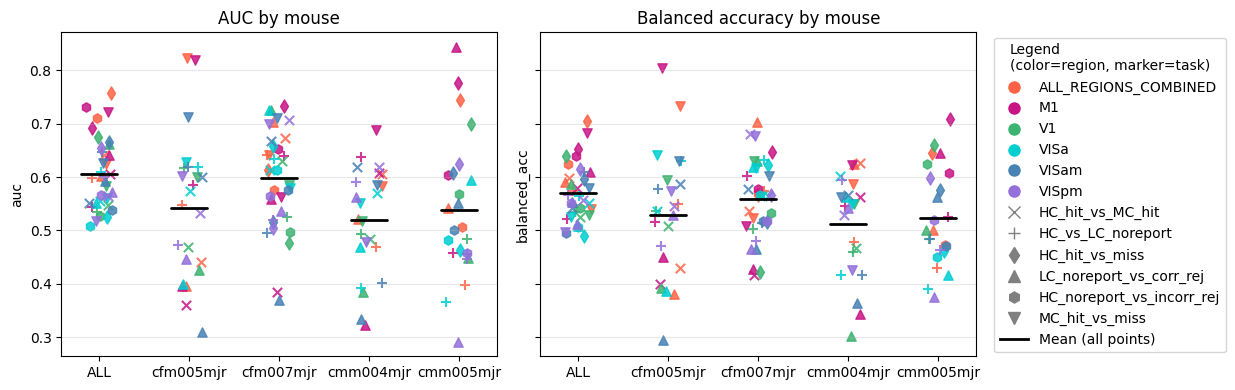

In [122]:
MIN_PER_CLASS = 25

# ---- USER CONTROLS ----
region_order = ["ALL_REGIONS_COMBINED", "M1", "V1", "VISa", "VISam", "VISpm"]
region_colors = ["tomato", "mediumvioletred", "mediumseagreen", "darkturquoise", "steelblue", "mediumpurple"]

task_order = [
    "HC_hit_vs_MC_hit",
    "HC_vs_LC_noreport",
    "HC_hit_vs_miss",
    "LC_noreport_vs_corr_rej",
    "HC_noreport_vs_incorr_rej",
    "MC_hit_vs_miss"
]
task_markers = ["x", "+", "d", "^", "h", "v"]

MEAN_LINE_HALF_WIDTH = 0.20   # half-width of the horizontal mean line (in x-axis units)
MEAN_LINE_LW = 2.0
MEAN_COLOR = "black"
MEAN_LABEL = "Mean (all points)"
# ----------------------

mice_groups = [
    ("ALL", mice),
    ("cfm005mjr", ["cfm005mjr"]),
    ("cfm007mjr", ["cfm007mjr"]),
    ("cmm004mjr", ["cmm004mjr"]),
    ("cmm005mjr", ["cmm005mjr"]),
]

# Collect results
rows = []
for name, mice_list in mice_groups:
    res = evaluate_tasks_across_regions(
        df=df,
        tasks=tasks,
        feature_prefix="log_",
        mice=mice_list,
        random_state=0,
        test_size=0.2,
    ).copy()
    res["mouse_group"] = name
    rows.append(res)

all_res = pd.concat(rows, ignore_index=True)

# Filter small class counts
def min_class_count(class_counts):
    return int(min(class_counts.values())) if isinstance(class_counts, dict) and len(class_counts) else np.nan

all_res["min_class_n"] = all_res["class_counts"].apply(min_class_count)
before = len(all_res)
all_res = all_res[all_res["min_class_n"] >= MIN_PER_CLASS].copy()
after = len(all_res)
print(f"Filtered runs by min class size >= {MIN_PER_CLASS}: {before} -> {after}")

# Ordering + mappings
mouse_order = ["ALL"] + [name for name, _ in mice_groups if name != "ALL"]
all_res["mouse_group"] = pd.Categorical(all_res["mouse_group"], categories=mouse_order, ordered=True)

present_regions = sorted(all_res["region"].unique())
region_to_color = {r: region_colors[i] for i, r in enumerate(region_order) if r in present_regions}

present_tasks = sorted(all_res["task"].unique())
task_to_marker = {t: task_markers[i] for i, t in enumerate(task_order) if t in present_tasks}

from matplotlib.lines import Line2D

def plot_metric(ax, metric, title):
    # Points
    for (mouse_g, region, task), dsub in all_res.groupby(["mouse_group", "region", "task"], dropna=False):
        vals = dsub[metric].dropna().values
        if len(vals) == 0:
            continue

        x0 = mouse_order.index(str(mouse_g))
        x = np.full(len(vals), x0, dtype=float) + (np.random.rand(len(vals)) - 0.5) * 0.30

        ax.scatter(
            x,
            vals,
            s=45,
            alpha=0.85,
            marker=task_to_marker.get(task, "o"),
            color=region_to_color.get(region, "gray"),
            edgecolor=region_to_color.get(region, "gray"),
        )

    # Mean line per mouse (mean across all points for that mouse)
    for i, mouse_g in enumerate(mouse_order):
        vals = all_res.loc[all_res["mouse_group"] == mouse_g, metric].dropna().values
        if len(vals) == 0:
            continue
        m = float(np.mean(vals))
        ax.plot([i - MEAN_LINE_HALF_WIDTH, i + MEAN_LINE_HALF_WIDTH], [m, m],
                color=MEAN_COLOR, linewidth=MEAN_LINE_LW, solid_capstyle="round", zorder=5)

    ax.set_xticks(range(len(mouse_order)))
    ax.set_xticklabels(mouse_order)
    ax.set_ylabel(metric)
    ax.set_title(title)
    #ax.set_ylim(0.44, 0.92)
    ax.grid(True, axis="y", alpha=0.3)

# Legend handles
region_handles = [
    Line2D([0], [0], marker="o", linestyle="None", markersize=8,
           markerfacecolor=region_to_color[r], markeredgecolor=region_to_color[r], label=r)
    for r in region_order if r in region_to_color
]

task_handles = [
    Line2D([0], [0], marker=task_to_marker[t], linestyle="None", markersize=8,
           markerfacecolor="gray", markeredgecolor="gray", label=t)
    for t in task_order if t in task_to_marker
]

mean_handle = Line2D([0], [0], color=MEAN_COLOR, linewidth=MEAN_LINE_LW, label=MEAN_LABEL)

handles = region_handles + task_handles + [mean_handle]

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4), sharey=True)

plot_metric(axes[0], "auc", f"AUC by mouse")
plot_metric(axes[1], "balanced_acc", f"Balanced accuracy by mouse")

fig.legend(
    handles=handles,
    loc="center right",
    bbox_to_anchor=(0.99, 0.5),
    frameon=True,
    title="Legend\n(color=region, marker=task)",
)

# Tight layout with only a small reserved strip for the legend
plt.tight_layout(rect=[0, 0, 0.80, 1])
plt.show()

## temporal dependence with feature ablation

In [11]:
# --- Pre vs Post offset contribution test (feature ablation) ---
# Assumes you already have:
#   - df (features dataframe)
#   - mice list
#   - filter_df, apply_task_map, pivot_regions_wide, run_decode_once (from earlier cells)

def _time_from_feature_col(col: str) -> float:
    """
    Extract the time-bin start from a feature column like:
      log_theta_-1.00
      bl_high_gamma_0.25
    Returns float time start (e.g. -1.00, 0.25)
    """
    base = col.split("_", 1)[1]          # strip "log_" or "bl_"
    _, t = base.rsplit("_", 1)           # split "..._<time>"
    return float(t)

def split_feature_cols_pre_post(df_in: pd.DataFrame, feature_prefix="log_", split_time=0.0):
    """
    Returns (pre_cols, post_cols, both_cols) based on time-bin start relative to split_time.
    - pre: time < split_time
    - post: time >= split_time
    """
    cols = [c for c in df_in.columns if c.startswith(feature_prefix)]
    pre_cols, post_cols = [], []
    for c in cols:
        t = _time_from_feature_col(c)
        if t < split_time:
            pre_cols.append(c)
        else:
            post_cols.append(c)
    return pre_cols, post_cols, cols

def run_decode_once_with_cols(
    df_labeled: pd.DataFrame,
    feature_cols: list[str],
    combine_regions=False,
    feature_prefix="log_",
    label_col="y",
    test_size=0.2,
    random_state=0,
    class_weight="balanced",
    C=1.0,
    max_iter=3000,
):
    """
    Same as run_decode_once, but uses exactly the provided feature_cols.
    For combine_regions=True, it will pivot and then select columns that match these features
    across regions (e.g. M1__log_theta_-1.00, V1__log_theta_-1.00, ...).
    """
    if combine_regions:
        X_df, y_series = pivot_regions_wide(df_labeled, feature_prefix=feature_prefix, label_col=label_col)

        # Expand requested feature_cols into region-prefixed columns
        # e.g. want "log_theta_-1.00" -> select "M1__log_theta_-1.00", "V1__log_theta_-1.00", ...
        want = []
        for col in feature_cols:
            want.extend([c for c in X_df.columns if c.endswith(f"__{col}")])

        X = X_df[want].values
        y = y_series.values
    else:
        d = df_labeled.drop_duplicates("trial_id")
        X = d[feature_cols].values
        y = d[label_col].values

    # counts
    uniq, cnt = np.unique(y, return_counts=True)
    class_counts = dict(zip(uniq.tolist(), cnt.tolist()))

    # split
    strat = y if len(np.unique(y)) > 1 else None
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=strat
    )

    # standardize
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # model
    clf = LogisticRegression(
        penalty="l2",
        class_weight=class_weight,
        C=C,
        max_iter=max_iter,
        multi_class="auto",
    )
    clf.fit(X_train, y_train)

    # predict
    y_pred = clf.predict(X_test)
    bal_acc = balanced_accuracy_score(y_test, y_pred)

    # auc only for binary
    auc = np.nan
    if len(np.unique(y)) == 2:
        y_prob = clf.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_prob)

    return {
        "n_total": int(len(y)),
        "class_counts": class_counts,
        "balanced_acc": float(bal_acc),
        "auc": float(auc) if not np.isnan(auc) else np.nan,
        "n_features": int(X.shape[1]),
    }

def split_feature_cols_three_windows(
    df_in: pd.DataFrame,
    feature_prefix="log_",
    pre_window=(-1.0, -0.5),
    during_window=(-0.5, 0.0),
    post_window=(0.0, 0.5),
):
    """
    Split feature columns into three time windows based on the feature time-bin start.

    Windows are half-open: [start, end)
      PRE:    [-1.0, -0.5)
      DURING: [-0.5,  0.0)
      POST:   [ 0.0,  0.5)

    Returns: (pre_cols, during_cols, post_cols, all_cols)
    """
    cols = [c for c in df_in.columns if c.startswith(feature_prefix)]
    pre_cols, during_cols, post_cols = [], [], []

    for c in cols:
        t = _time_from_feature_col(c)

        if (t >= pre_window[0]) and (t < pre_window[1]):
            pre_cols.append(c)
        elif (t >= during_window[0]) and (t < during_window[1]):
            during_cols.append(c)
        elif (t >= post_window[0]) and (t < post_window[1]):
            post_cols.append(c)

    return pre_cols, during_cols, post_cols, cols

def pre_during_post_ablation(
    df: pd.DataFrame,
    task_map: dict,
    regions: str | list[str] = "M1",
    feature_prefix="log_",
    combine_regions=False,
    mice=None,
    test_size=0.2,
    random_state=0,
    pre_window=(-1.0, -0.5),
    during_window=(-0.5, 0.0),
    post_window=(0.0, 0.5),
):
    """
    Runs 4 decodes:
      - PRE only    (default: [-1.0, -0.5))
      - DURING only (default: [-0.5,  0.0))
      - POST only   (default: [ 0.0,  0.5))
      - ALL         (all time bins in the dataset for this prefix)

    Returns a compact DataFrame summary.
    """
    # Filter + label
    df_sub = filter_df(df, regions=regions if not combine_regions else "all", mice=mice)
    df_lab = apply_task_map(df_sub, task_map, label_col="y")

    if len(df_lab) == 0:
        raise ValueError("No labeled rows after applying task_map and filters.")

    pre_cols, during_cols, post_cols, all_cols = split_feature_cols_three_windows(
        df_lab,
        feature_prefix=feature_prefix,
        pre_window=pre_window,
        during_window=during_window,
        post_window=post_window,
    )

    rows = []
    for which, cols in [
        ("PRE", pre_cols),
        ("DURING", during_cols),
        ("POST", post_cols),
        ("ALL", all_cols),
    ]:
        summ = run_decode_once_with_cols(
            df_lab,
            feature_cols=cols,
            combine_regions=combine_regions,
            feature_prefix=feature_prefix,
            label_col="y",
            test_size=test_size,
            random_state=random_state,
        )
        rows.append({
            "which": which,
            "regions": "ALL_COMBINED" if combine_regions else (regions if isinstance(regions, str) else "+".join(regions)),
            "feature_prefix": feature_prefix,
            "n_total": summ["n_total"],
            "class_counts": summ["class_counts"],
            "n_features": summ["n_features"],
            "balanced_acc": summ["balanced_acc"],
            "auc": summ["auc"],
        })

    out = pd.DataFrame(rows)
    out["class_counts_str"] = out["class_counts"].apply(lambda d: ", ".join([f"{k}:{v}" for k, v in d.items()]))
    return out

# -----------------------------
# EXAMPLES
# -----------------------------

task_MC_report_vs_noreport = {
    0: ["MC No Report (8)"],
    1: ["MC Hit (2)", "MC Miss (5)"],
}

task_all_report_vs_noreport = {
    0: ["HC No Report (9)", "MC No Report (8)", "LC No Report (7)"],
    1: ["HC Hit (3)", "Incorrect Reject (6)", "MC Hit (2)", "MC Miss (5)","Correct Rejection (4)"],
}

task_hit_vs_miss = {
    0: ["Incorrect Reject (6)", "MC Miss (5)"],
    1: ["HC Hit (3)", "MC Hit (2)"],
}

task_MC_hit_vs_miss = {
    0: ["MC Miss (5)"],
    1: ["MC Hit (2)"],
}

mice = ['cfm005mjr', 'cfm007mjr', 'cmm004mjr', 'cmm005mjr']

print("MC Report vs. No Report")
display(pre_during_post_ablation(
    df=df,
    task_map=task_MC_report_vs_noreport,
    regions="M1",
    feature_prefix="log_",
    combine_regions=False,
    mice=mice,
))

print("All Report vs. No Report")
display(pre_during_post_ablation(
    df=df,
    task_map=task_all_report_vs_noreport,
    regions="M1",
    feature_prefix="log_",
    combine_regions=False,
    mice=mice,
))

print("HC & MC Hit vs Miss")
display(pre_during_post_ablation(
    df=df,
    task_map=task_hit_vs_miss,
    regions="M1",
    feature_prefix="log_",
    combine_regions=False,
    mice=mice,
))

print("MC Hit vs Miss")
display(pre_during_post_ablation(
    df=df,
    task_map=task_MC_hit_vs_miss,
    regions="M1",
    feature_prefix="log_",
    combine_regions=False,
    mice=mice,
))

MC Report vs. No Report


,which,regions,feature_prefix,n_total,class_counts,n_features,balanced_acc,auc,class_counts_str
0,PRE,M1,log_,1659,"{0.0: 865, 1.0: 794}",10,0.607900,0.624023,"0.0:865, 1.0:794"
1,DURING,M1,log_,1659,"{0.0: 865, 1.0: 794}",10,0.597957,0.645799,"0.0:865, 1.0:794"
2,POST,M1,log_,1659,"{0.0: 865, 1.0: 794}",10,0.660432,0.718944,"0.0:865, 1.0:794"
3,ALL,M1,log_,1659,"{0.0: 865, 1.0: 794}",30,0.650998,0.700622,"0.0:865, 1.0:794"


All Report vs. No Report


,which,regions,feature_prefix,n_total,class_counts,n_features,balanced_acc,auc,class_counts_str
0,PRE,M1,log_,4328,"{0.0: 2412, 1.0: 1916}",10,0.611320,0.672672,"0.0:2412, 1.0:1916"
1,DURING,M1,log_,4328,"{0.0: 2412, 1.0: 1916}",10,0.644446,0.707447,"0.0:2412, 1.0:1916"
2,POST,M1,log_,4328,"{0.0: 2412, 1.0: 1916}",10,0.679154,0.752834,"0.0:2412, 1.0:1916"
3,ALL,M1,log_,4328,"{0.0: 2412, 1.0: 1916}",30,0.692836,0.770235,"0.0:2412, 1.0:1916"


HC & MC Hit vs Miss


,which,regions,feature_prefix,n_total,class_counts,n_features,balanced_acc,auc,class_counts_str
0,PRE,M1,log_,1745,"{0.0: 576, 1.0: 1169}",10,0.488759,0.466258,"0.0:576, 1.0:1169"
1,DURING,M1,log_,1745,"{0.0: 576, 1.0: 1169}",10,0.648291,0.707209,"0.0:576, 1.0:1169"
2,POST,M1,log_,1745,"{0.0: 576, 1.0: 1169}",10,0.609755,0.664660,"0.0:576, 1.0:1169"
3,ALL,M1,log_,1745,"{0.0: 576, 1.0: 1169}",30,0.708863,0.758082,"0.0:576, 1.0:1169"


MC Hit vs Miss


,which,regions,feature_prefix,n_total,class_counts,n_features,balanced_acc,auc,class_counts_str
0,PRE,M1,log_,794,"{0.0: 408, 1.0: 386}",10,0.491448,0.540386,"0.0:408, 1.0:386"
1,DURING,M1,log_,794,"{0.0: 408, 1.0: 386}",10,0.608885,0.653310,"0.0:408, 1.0:386"
2,POST,M1,log_,794,"{0.0: 408, 1.0: 386}",10,0.659645,0.710326,"0.0:408, 1.0:386"
3,ALL,M1,log_,794,"{0.0: 408, 1.0: 386}",30,0.654340,0.723630,"0.0:408, 1.0:386"


## p-values and null distributions from label shuffles

In [12]:
def _prep_Xy(
    df_labeled: pd.DataFrame,
    feature_prefix="log_",
    combine_regions=False,
    label_col="y",
):
    """
    Build X, y, trial_ids from labeled df.
    For combine_regions=True: one row per trial_id with concatenated region features.
    For combine_regions=False: expects df is already filtered to one region; uses drop_duplicates(trial_id).
    """
    if combine_regions:
        X_df, y_series = pivot_regions_wide(df_labeled, feature_prefix=feature_prefix, label_col=label_col)
        X = X_df.values
        y = y_series.values
        trial_ids = np.array(X_df.index)
    else:
        d = df_labeled.drop_duplicates("trial_id").copy()
        feature_cols = [c for c in d.columns if c.startswith(feature_prefix)]
        X = d[feature_cols].values
        y = d[label_col].values
        trial_ids = d["trial_id"].values

    return X, y, trial_ids

def _split_and_score(
    X: np.ndarray,
    y: np.ndarray,
    test_size=0.2,
    random_state=0,
    class_weight="balanced",
    C=1.0,
    max_iter=3000,
):
    """
    Train/test split, standardize, fit logistic regression, return (bal_acc, auc).
    AUC returned as np.nan if not binary labels.
    """
    uniq = np.unique(y)
    strat = y if len(uniq) > 1 else None
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=strat
    )

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    clf = LogisticRegression(
        penalty="l2",
        class_weight=class_weight,
        C=C,
        max_iter=max_iter,
        multi_class="auto",
    )
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)
    bal_acc = balanced_accuracy_score(y_test, y_pred)

    auc = np.nan
    if len(np.unique(y)) == 2:
        y_prob = clf.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_prob)

    return float(bal_acc), float(auc) if not np.isnan(auc) else np.nan

def _shuffle_labels(y: np.ndarray, groups: np.ndarray | None, rng: np.random.Generator):
    """
    Shuffle y globally if groups is None, else shuffle within each group.
    Returns y_shuf (new array).
    """
    y_shuf = y.copy()
    if groups is None:
        rng.shuffle(y_shuf)
        return y_shuf

    # within-group shuffle
    for g in np.unique(groups):
        idx = np.where(groups == g)[0]
        rng.shuffle(y_shuf[idx])
    return y_shuf

def null_distribution_label_shuffle(
    df_labeled: pd.DataFrame,
    feature_prefix="log_",
    combine_regions=False,
    label_col="y",
    group_col: str | None = "recording",
    n_shuffles=1000,
    test_size=0.2,
    random_state=0,
    class_weight="balanced",
    C=1.0,
    max_iter=3000,
    verbose=False,
):
    """
    Builds a null distribution for balanced accuracy + AUC by shuffling labels.

    Returns a dict with:
      - real_bal_acc, real_auc
      - null_bal_acc: np.array (n_shuffles,)
      - null_auc: np.array (n_shuffles,) (nan if non-binary)
      - class_counts
      - n_total
    """
    # Build X, y
    X, y, trial_ids = _prep_Xy(df_labeled, feature_prefix=feature_prefix, combine_regions=combine_regions, label_col=label_col)

    # Groups for within-recording shuffle (recommended)
    groups = None
    if group_col is not None:
        # Need group info per trial_id
        if combine_regions:
            # df has multiple rows per trial_id; drop_duplicates gives trial-level group label
            d = df_labeled.drop_duplicates("trial_id").set_index("trial_id")
            groups = d.loc[trial_ids, group_col].values
        else:
            d = df_labeled.drop_duplicates("trial_id")
            # trial_ids align with d order in _prep_Xy when not combined
            groups = d[group_col].values

    # Real performance (unshuffled)
    real_bal_acc, real_auc = _split_and_score(
        X, y,
        test_size=test_size,
        random_state=random_state,
        class_weight=class_weight,
        C=C,
        max_iter=max_iter,
    )

    uniq, cnt = np.unique(y, return_counts=True)
    class_counts = dict(zip(uniq.tolist(), cnt.tolist()))

    # Null distributions
    rng = np.random.default_rng(random_state)
    null_bal = np.zeros(n_shuffles, dtype=float)
    null_auc = np.full(n_shuffles, np.nan, dtype=float)

    for i in range(n_shuffles):
        y_shuf = _shuffle_labels(y, groups=groups, rng=rng)

        b, a = _split_and_score(
            X, y_shuf,
            test_size=test_size,
            random_state=random_state,   # keep split identical across shuffles (nice for fairness)
            class_weight=class_weight,
            C=C,
            max_iter=max_iter,
        )
        null_bal[i] = b
        null_auc[i] = a

        if verbose and (i % max(1, n_shuffles // 10) == 0):
            print(f"shuffle {i}/{n_shuffles}: bal={b:.3f}, auc={a:.3f}")

    return {
        "n_total": int(len(y)),
        "class_counts": class_counts,
        "real_bal_acc": real_bal_acc,
        "real_auc": real_auc,
        "null_bal_acc": null_bal,
        "null_auc": null_auc,
        "group_col": group_col,
        "n_shuffles": int(n_shuffles),
    }

def summarize_null(result: dict, print_res: bool = False):
    """
    Compact summary including a permutation p-value (upper-tail).
    """
    null_bal = result["null_bal_acc"]
    null_auc = result["null_auc"]

    real_bal = result["real_bal_acc"]
    real_auc = result["real_auc"]

    # p-values: fraction of null >= real (add 1 for conservative estimate)
    p_bal = (np.sum(null_bal >= real_bal) + 1) / (len(null_bal) + 1)

    if np.isnan(real_auc):
        p_auc = np.nan
        auc_str = "AUC: n/a (non-binary labels)"
    else:
        valid = ~np.isnan(null_auc)
        p_auc = (np.sum(null_auc[valid] >= real_auc) + 1) / (np.sum(valid) + 1)
        auc_str = f"AUC: real={real_auc:.3f} | null mean±sd={np.nanmean(null_auc):.3f}±{np.nanstd(null_auc):.3f} | p≈{p_auc:.4g}"

    if print_res:
        print(f"N={result['n_total']} | class_counts={result['class_counts']} | group_shuffle={result['group_col']}")
        print(f"BalAcc: real={real_bal:.3f} | null mean±sd={null_bal.mean():.3f}±{null_bal.std():.3f} | p≈{p_bal:.4g}")
        print(auc_str)

    return {"p_bal": p_bal, "p_auc": p_auc}

def plot_null_hist(result: dict, metric="auc", bins=30):
    """
    Quick visualization: histogram of null with real value shown.
    metric: 'auc' or 'bal_acc'
    """
    if metric == "auc":
        vals = result["null_auc"]
        real = result["real_auc"]
        title = "Null distribution: ROC AUC"
        xlabel = "AUC"
    else:
        vals = result["null_bal_acc"]
        real = result["real_bal_acc"]
        title = "Null distribution: Balanced accuracy"
        xlabel = "Balanced accuracy"

    vals = vals[~np.isnan(vals)]
    plt.figure(figsize=(5.5, 3.5))
    plt.hist(vals, bins=bins)
    plt.axvline(real, linestyle="--", linewidth=2)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

def decode_with_null(
    df_labeled: pd.DataFrame,
    feature_prefix="log_",
    combine_regions=False,
    label_col="y",
    test_size=0.2,
    random_state=0,
    class_weight="balanced",
    C=1.0,
    show_plots=True,
    # null options
    do_null=False,
    n_shuffles=1000,
    group_col="recording",
    show_null_plots=True,
):
    """
    Wrapper around your decode() that optionally also computes label-shuffle null distributions.
    Returns:
      - (clf, scaler) if do_null=False
      - (clf, scaler, null_result) if do_null=True
    """
    clf, scaler = decode(
        df_labeled=df_labeled,
        feature_prefix=feature_prefix,
        combine_regions=combine_regions,
        label_col=label_col,
        test_size=test_size,
        random_state=random_state,
        class_weight=class_weight,
        C=C,
        show_plots=show_plots,
    )

    if not do_null:
        return clf, scaler

    null_res = null_distribution_label_shuffle(
        df_labeled=df_labeled,
        feature_prefix=feature_prefix,
        combine_regions=combine_regions,
        label_col=label_col,
        group_col=group_col,
        n_shuffles=n_shuffles,
        test_size=test_size,
        random_state=random_state,
        class_weight=class_weight,
        C=C,
    )

    summarize_null(null_res)

    if show_null_plots:
        plot_null_hist(null_res, metric="bal_acc")
        plot_null_hist(null_res, metric="auc")

    return clf, scaler, null_res

def evaluate_tasks_across_regions_with_null(
    df: pd.DataFrame,
    tasks: dict,
    feature_prefix="log_",
    mice=None,
    random_state=0,
    test_size=0.2,
    # null options
    do_null=False,
    n_shuffles=1000,
    group_col="recording",
):
    """
    Like evaluate_tasks_across_regions, but optionally adds null summary stats per (task, region).

    Adds columns when do_null=True:
      - null_auc_mean, null_auc_std, p_auc
      - null_bal_mean, null_bal_std, p_bal
    """
    results = []

    regions = sorted(df["region"].unique())
    regions_plus = regions + ["ALL_REGIONS_COMBINED"]

    for task_name, task_map in tasks.items():
        for region in regions_plus:

            if region == "ALL_REGIONS_COMBINED":
                df_sub = filter_df(df, regions="all", mice=mice)
                combine_regions = True
            else:
                df_sub = filter_df(df, regions=region, mice=mice)
                combine_regions = False

            df_lab = apply_task_map(df_sub, task_map, label_col="y")
            if len(df_lab) == 0:
                continue

            summary = run_decode_once(
                df_lab,
                feature_prefix=feature_prefix,
                combine_regions=combine_regions,
                label_col="y",
                random_state=random_state,
                test_size=test_size,
            )

            row = {
                "task": task_name,
                "region": region,
                "feature_prefix": feature_prefix,
                "n_total": summary["n_total"],
                "class_counts": summary["class_counts"],
                "balanced_acc": summary["balanced_acc"],
                "auc": summary["auc"],
            }

            if do_null:
                null_res = null_distribution_label_shuffle(
                    df_labeled=df_lab,
                    feature_prefix=feature_prefix,
                    combine_regions=combine_regions,
                    label_col="y",
                    group_col=group_col,
                    n_shuffles=n_shuffles,
                    test_size=test_size,
                    random_state=random_state,
                )
                p = summarize_null(null_res)

                # summarize null distributions
                row["null_bal_mean"] = float(np.mean(null_res["null_bal_acc"]))
                row["null_bal_std"]  = float(np.std(null_res["null_bal_acc"]))
                row["p_bal"]         = float(p["p_bal"])

                if np.isnan(null_res["real_auc"]):
                    row["null_auc_mean"] = np.nan
                    row["null_auc_std"]  = np.nan
                    row["p_auc"]         = np.nan
                else:
                    vals = null_res["null_auc"][~np.isnan(null_res["null_auc"])]
                    row["null_auc_mean"] = float(np.mean(vals))
                    row["null_auc_std"]  = float(np.std(vals))
                    row["p_auc"]         = float(p["p_auc"])

            results.append(row)

    results_df = pd.DataFrame(results)

    if len(results_df) > 0:
        results_df["class_counts_str"] = results_df["class_counts"].apply(
            lambda d: ", ".join([f"{k}:{v}" for k, v in d.items()])
        )
        results_df = results_df.sort_values(["task", "balanced_acc"], ascending=[True, False]).reset_index(drop=True)

    return results_df

N total: 4328 | N test: 866
Class counts: {np.float64(0.0): np.int64(2412), np.float64(1.0): np.int64(1916)}
Balanced accuracy: 0.6928357902361761
ROC AUC: 0.7702349869451697

Classification report:
              precision    recall  f1-score   support

         0.0       0.75      0.67      0.71       483
         1.0       0.63      0.71      0.67       383

    accuracy                           0.69       866
   macro avg       0.69      0.69      0.69       866
weighted avg       0.70      0.69      0.69       866



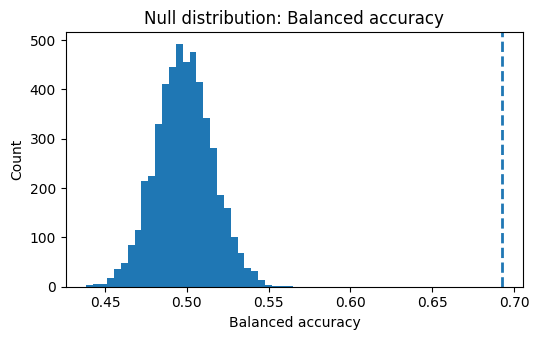

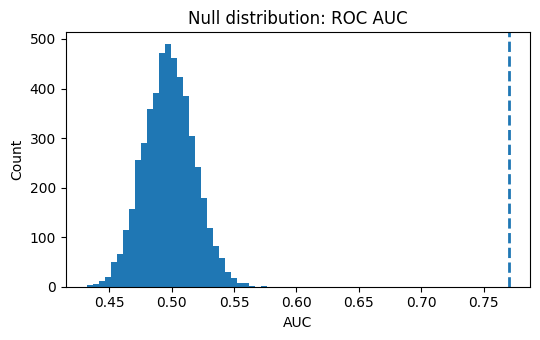

In [15]:
df_sub = filter_df(df, regions="M1", mice=mice)
df_lab = apply_task_map(df_sub, task_all_report_vs_noreport, label_col="y")

clf, scaler, null_res = decode_with_null(
    df_lab,
    feature_prefix="log_",
    combine_regions=False,
    do_null=True,
    n_shuffles=5000,
    group_col=None,          # set to None to shuffle globally
    show_plots=False,        # your normal plots
    show_null_plots=True,    # null histograms
)

In [ ]:
results_df = evaluate_tasks_across_regions_with_null(
    df=df,
    tasks=tasks,
    feature_prefix="log_",
    mice=mice,
    do_null=True,
    n_shuffles=1000,   #use 1000+ for real results
    group_col=None,
)
display(results_df)

Filtered runs by min class size >= 25: 180 -> 144
Saved cache: sig_filtered_points_shuf100_min25.csv


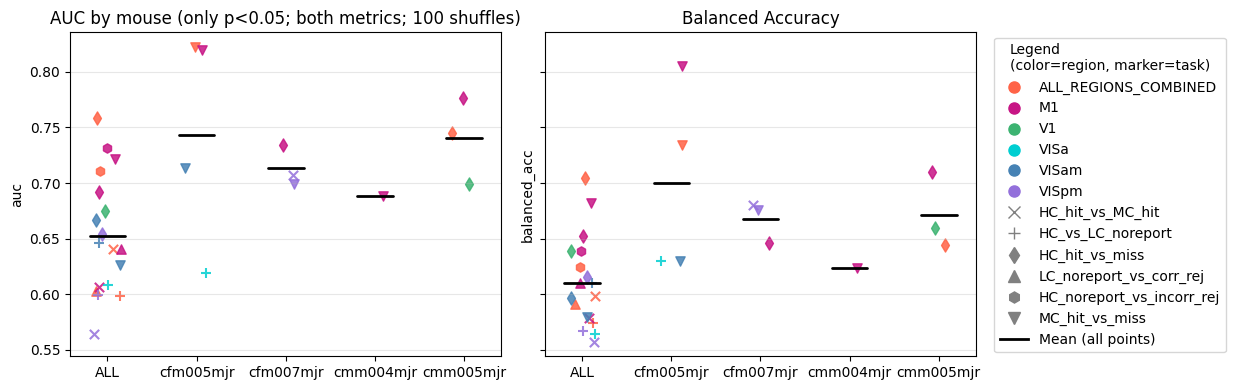

Points significant for BOTH AUC and balanced_acc: 29


In [139]:
MIN_PER_CLASS = 25
N_SHUFFLES = 100
ALPHA = 0.05

# ---- USER CONTROLS ----
region_order = ["ALL_REGIONS_COMBINED", "M1", "V1", "VISa", "VISam", "VISpm"]
region_colors = ["tomato", "mediumvioletred", "mediumseagreen", "darkturquoise", "steelblue", "mediumpurple"]

task_order = [
    "HC_hit_vs_MC_hit",
    "HC_vs_LC_noreport",
    "HC_hit_vs_miss",
    "LC_noreport_vs_corr_rej",
    "HC_noreport_vs_incorr_rej",
    "MC_hit_vs_miss"
]
task_markers = ["x", "+", "d", "^", "h", "v"]

MEAN_LINE_HALF_WIDTH = 0.20
MEAN_LINE_LW = 2.0
MEAN_COLOR = "black"
MEAN_LABEL = "Mean (all points)"
# ----------------------

mice_groups = [
    ("ALL", mice),
    ("cfm005mjr", ["cfm005mjr"]),
    ("cfm007mjr", ["cfm007mjr"]),
    ("cmm004mjr", ["cmm004mjr"]),
    ("cmm005mjr", ["cmm005mjr"]),
]

# ----------------------------
# Helper: min class count
def min_class_count(class_counts):
    return int(min(class_counts.values())) if isinstance(class_counts, dict) and len(class_counts) else np.nan

# Helper: compute p-values for one labeled df
def compute_pvals_for_setting(df_lab, combine_regions, feature_prefix="log_", label_col="y",
                              test_size=0.2, random_state=0, n_shuffles=100, group_col=None):
    null_res = null_distribution_label_shuffle(
        df_labeled=df_lab,
        feature_prefix=feature_prefix,
        combine_regions=combine_regions,
        label_col=label_col,
        group_col=group_col,
        n_shuffles=n_shuffles,
        test_size=test_size,
        random_state=random_state,
        class_weight="balanced",
        C=1.0,
        max_iter=3000,
        verbose=False,
    )
    p = summarize_null(null_res, print_res=False)
    return {
        "p_bal": float(p["p_bal"]),
        "p_auc": float(p["p_auc"]) if not (p["p_auc"] is None or np.isnan(p["p_auc"])) else np.nan,
        "null_bal_mean": float(np.mean(null_res["null_bal_acc"])),
        "null_bal_std": float(np.std(null_res["null_bal_acc"])),
        "null_auc_mean": float(np.nanmean(null_res["null_auc"])),
        "null_auc_std": float(np.nanstd(null_res["null_auc"])),
    }

# ----------------------------
# 1) Compute decode metrics + p-values per point
rows = []
regions_all = sorted(df["region"].unique())
regions_plus = regions_all + ["ALL_REGIONS_COMBINED"]

for name, mice_list in mice_groups:
    for task_name, task_map in tasks.items():
        for region in regions_plus:

            if region == "ALL_REGIONS_COMBINED":
                df_sub = filter_df(df, regions="all", mice=mice_list)
                combine_regions = True
            else:
                df_sub = filter_df(df, regions=region, mice=mice_list)
                combine_regions = False

            df_lab = apply_task_map(df_sub, task_map, label_col="y")
            if len(df_lab) == 0:
                continue

            # quick decode (real)
            summ = run_decode_once(
                df_lab,
                feature_prefix="log_",
                combine_regions=combine_regions,
                label_col="y",
                random_state=0,
                test_size=0.2,
            )

            row = {
                "mouse_group": name,
                "task": task_name,
                "region": region,
                "n_total": summ["n_total"],
                "class_counts": summ["class_counts"],
                "balanced_acc": summ["balanced_acc"],
                "auc": summ["auc"],
            }

            # min-class filter before doing expensive nulls
            row["min_class_n"] = min_class_count(row["class_counts"])
            if row["min_class_n"] < MIN_PER_CLASS:
                rows.append(row)
                continue

            # label-shuffle p-values
            pinfo = compute_pvals_for_setting(
                df_lab,
                combine_regions=combine_regions,
                feature_prefix="log_",
                label_col="y",
                test_size=0.2,
                random_state=0,
                n_shuffles=N_SHUFFLES,
                group_col=None,
            )
            row.update(pinfo)

            rows.append(row)

all_res = pd.DataFrame(rows)

# Filter small class counts (for plotting and significance)
before = len(all_res)
all_res = all_res[all_res["min_class_n"] >= MIN_PER_CLASS].copy()
after = len(all_res)
print(f"Filtered runs by min class size >= {MIN_PER_CLASS}: {before} -> {after}")

# Save cache so you don't recompute nulls every time
cache_path = f"sig_filtered_points_shuf{N_SHUFFLES}_min{MIN_PER_CLASS}.csv"
all_res.to_csv(cache_path, index=False)
print("Saved cache:", cache_path)

# ----------------------------
# 2) Plotting setup (same as yours)
mouse_order = ["ALL"] + [name for name, _ in mice_groups if name != "ALL"]
all_res["mouse_group"] = pd.Categorical(all_res["mouse_group"], categories=mouse_order, ordered=True)

present_regions = sorted(all_res["region"].unique())
region_to_color = {r: region_colors[i] for i, r in enumerate(region_order) if r in present_regions}

present_tasks = sorted(all_res["task"].unique())
task_to_marker = {t: task_markers[i] for i, t in enumerate(task_order) if t in present_tasks}

from matplotlib.lines import Line2D

# Add a flag so BOTH subplots use the same set of points:
# only plot datapoints that are significant for BOTH AUC and balanced accuracy.

PLOT_REQUIRE_BOTH_SIG = True   # <--- NEW FLAG

def plot_metric_sig(ax, metric, title):
    dplot = all_res.copy()

    # Drop rows with missing p-values (e.g. AUC nan for non-binary)
    dplot = dplot[dplot["p_bal"].notna()]

    if PLOT_REQUIRE_BOTH_SIG:
        dplot = dplot[dplot["p_auc"].notna()]  # required if we demand both
        dplot = dplot[(dplot["p_bal"] < ALPHA) & (dplot["p_auc"] < ALPHA)]
    else:
        # Metric-specific significance (previous behavior)
        if metric == "auc":
            dplot = dplot[dplot["p_auc"].notna()]
            dplot = dplot[dplot["p_auc"] < ALPHA]
        else:
            dplot = dplot[dplot["p_bal"] < ALPHA]

    # Points
    for (mouse_g, region, task), dsub in dplot.groupby(["mouse_group", "region", "task"], dropna=False):
        vals = dsub[metric].dropna().values
        if len(vals) == 0:
            continue

        x0 = mouse_order.index(str(mouse_g))
        x = np.full(len(vals), x0, dtype=float) + (np.random.rand(len(vals)) - 0.5) * 0.30

        ax.scatter(
            x,
            vals,
            s=45,
            alpha=0.85,
            marker=task_to_marker.get(task, "o"),
            color=region_to_color.get(region, "gray"),
            edgecolor=region_to_color.get(region, "gray"),
        )

    # Mean line per mouse (mean across plotted points)
    for i, mouse_g in enumerate(mouse_order):
        vals = dplot.loc[dplot["mouse_group"] == mouse_g, metric].dropna().values
        if len(vals) == 0:
            continue
        m = float(np.mean(vals))
        ax.plot(
            [i - MEAN_LINE_HALF_WIDTH, i + MEAN_LINE_HALF_WIDTH],
            [m, m],
            color=MEAN_COLOR, linewidth=MEAN_LINE_LW, solid_capstyle="round", zorder=5
        )

    ax.set_xticks(range(len(mouse_order)))
    ax.set_xticklabels(mouse_order)
    ax.set_ylabel(metric)
    ax.set_title(title)
    ax.grid(True, axis="y", alpha=0.3)

# --- Re-make the figure using the updated plot function ---
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4), sharey=True)

suffix = "both metrics" if PLOT_REQUIRE_BOTH_SIG else "metric-specific"
plot_metric_sig(axes[0], "auc", f"AUC by mouse (only p<{ALPHA}; {suffix}; {N_SHUFFLES} shuffles)")
plot_metric_sig(axes[1], "balanced_acc", f"Balanced Accuracy")

fig.legend(
    handles=handles,
    loc="center right",
    bbox_to_anchor=(0.99, 0.5),
    frameon=True,
    title="Legend\n(color=region, marker=task)",
)

plt.tight_layout(rect=[0, 0, 0.80, 1])
plt.show()

# Useful count
if PLOT_REQUIRE_BOTH_SIG:
    n_both = int(np.sum(all_res["p_auc"].notna() & all_res["p_bal"].notna() &
                        (all_res["p_auc"] < ALPHA) & (all_res["p_bal"] < ALPHA)))
    print(f"Points significant for BOTH AUC and balanced_acc: {n_both}")
else:
    n_auc = int(np.sum(all_res["p_auc"].notna() & (all_res["p_auc"] < ALPHA)))
    n_bal = int(np.sum(all_res["p_bal"].notna() & (all_res["p_bal"] < ALPHA)))
    print(f"Points significant for AUC: {n_auc}")
    print(f"Points significant for balanced_acc: {n_bal}")

In [16]:
# =========================
# LDA vs Logistic Regression
# Drop-in cells for your notebook
# =========================
# Assumes you already have:
#   - df (features dataframe), mice list, tasks dict, filter_df, apply_task_map, pivot_regions_wide
#   - numpy as np, pandas as pd, matplotlib.pyplot as plt
#   - sklearn already installed
#
# This implements:
#   1) run_decode_once_model(...): one run with either LogisticRegression or LDA
#   2) evaluate_tasks_across_regions_model(...): compares LR vs LDA across regions + ALL_REGIONS_COMBINED
#   3) optional: per-task comparison plot

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis


def run_decode_once_model(
    df_labeled: pd.DataFrame,
    model: str = "lr",                 # "lr" or "lda"
    feature_prefix: str = "log_",
    combine_regions: bool = False,
    label_col: str = "y",
    test_size: float = 0.2,
    random_state: int = 0,
    # LR knobs
    class_weight="balanced",
    C: float = 1.0,
    max_iter: int = 3000,
):
    """
    Minimal decode runner for LR or LDA.

    Notes:
      - LR uses StandardScaler and class_weight (optional).
      - LDA typically does NOT need StandardScaler; but scaling won't hurt.
        Here we KEEP scaling for apples-to-apples, since your features are z-scored for LR.
      - AUC returned only for binary problems.
    """
    # Build X, y
    if combine_regions:
        X_df, y_series = pivot_regions_wide(df_labeled, feature_prefix=feature_prefix, label_col=label_col)
        X = X_df.values
        y = y_series.values
    else:
        d = df_labeled.drop_duplicates("trial_id")
        feature_cols = [c for c in d.columns if c.startswith(feature_prefix)]
        X = d[feature_cols].values
        y = d[label_col].values

    # counts
    uniq, cnt = np.unique(y, return_counts=True)
    class_counts = dict(zip(uniq.tolist(), cnt.tolist()))

    # split
    strat = y if len(np.unique(y)) > 1 else None
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=strat
    )

    # standardize (keep for consistency with LR runs)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    # model
    if model.lower() in ["lr", "logreg", "logistic"]:
        clf = LogisticRegression(
            penalty="l2",
            class_weight=class_weight,
            C=C,
            max_iter=max_iter,
            multi_class="auto",
        )
    elif model.lower() in ["lda", "fld", "fisher"]:
        # LDA supports class priors, but not class_weight directly.
        # If you want a "balanced" analogue, use priors=[0.5,0.5] for binary tasks.
        # We leave priors=None by default (uses empirical class frequencies).
        clf = LinearDiscriminantAnalysis(solver="svd")
    else:
        raise ValueError("model must be one of: 'lr' or 'lda'")

    clf.fit(X_train, y_train)

    # predict + metrics
    y_pred = clf.predict(X_test)
    bal_acc = balanced_accuracy_score(y_test, y_pred)

    auc = np.nan
    if len(np.unique(y)) == 2:
        # Both LR and LDA implement predict_proba
        y_prob = clf.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_prob)

    return {
        "n_total": int(len(y)),
        "class_counts": class_counts,
        "balanced_acc": float(bal_acc),
        "auc": float(auc) if not np.isnan(auc) else np.nan,
    }


def evaluate_tasks_across_regions_model(
    df: pd.DataFrame,
    tasks: dict,
    model: str = "lr",
    feature_prefix="log_",
    mice=None,
    random_state=0,
    test_size=0.2,
    # LR knobs
    class_weight="balanced",
    C=1.0,
):
    """
    Evaluate one model (LR or LDA) across:
      - each individual region
      - ALL_REGIONS_COMBINED
    Returns a results DataFrame with one row per (task, region).
    """
    results = []
    regions = sorted(df["region"].unique())
    regions_plus = regions + ["ALL_REGIONS_COMBINED"]

    for task_name, task_map in tasks.items():
        for region in regions_plus:

            if region == "ALL_REGIONS_COMBINED":
                df_sub = filter_df(df, regions="all", mice=mice)
                combine_regions = True
            else:
                df_sub = filter_df(df, regions=region, mice=mice)
                combine_regions = False

            df_lab = apply_task_map(df_sub, task_map, label_col="y")
            if len(df_lab) == 0:
                continue

            summ = run_decode_once_model(
                df_lab,
                model=model,
                feature_prefix=feature_prefix,
                combine_regions=combine_regions,
                label_col="y",
                test_size=test_size,
                random_state=random_state,
                class_weight=class_weight,
                C=C,
            )

            results.append({
                "model": model.upper(),
                "task": task_name,
                "region": region,
                "feature_prefix": feature_prefix,
                "n_total": summ["n_total"],
                "class_counts": summ["class_counts"],
                "balanced_acc": summ["balanced_acc"],
                "auc": summ["auc"],
            })

    out = pd.DataFrame(results)
    if len(out) > 0:
        out["class_counts_str"] = out["class_counts"].apply(
            lambda d: ", ".join([f"{k}:{v}" for k, v in d.items()])
        )
        out = out.sort_values(["task", "region"]).reset_index(drop=True)
    return out


def compare_lr_vs_lda(
    df: pd.DataFrame,
    tasks: dict,
    feature_prefix="log_",
    mice=None,
    random_state=0,
    test_size=0.2,
    class_weight="balanced",
    C=1.0,
):
    """
    Runs both LR and LDA and returns:
      - long table with both models
      - wide comparison table with LR/LDA side-by-side + deltas
    """
    res_lr = evaluate_tasks_across_regions_model(
        df, tasks,
        model="lr",
        feature_prefix=feature_prefix,
        mice=mice,
        random_state=random_state,
        test_size=test_size,
        class_weight=class_weight,
        C=C,
    )
    res_lda = evaluate_tasks_across_regions_model(
        df, tasks,
        model="lda",
        feature_prefix=feature_prefix,
        mice=mice,
        random_state=random_state,
        test_size=test_size,
    )

    res = pd.concat([res_lr, res_lda], ignore_index=True)

    # Wide
    wide = (
        res.pivot_table(index=["task", "region"], columns="model", values=["balanced_acc", "auc"])
           .reset_index()
    )
    # Flatten column names
    wide.columns = ["_".join([c for c in col if c != ""]).strip("_") for col in wide.columns.values]

    # Deltas (LDA - LR)
    if "auc_LDA" in wide.columns and "auc_LR" in wide.columns:
        wide["delta_auc_(LDA-LR)"] = wide["auc_LDA"] - wide["auc_LR"]
    if "balanced_acc_LDA" in wide.columns and "balanced_acc_LR" in wide.columns:
        wide["delta_bal_(LDA-LR)"] = wide["balanced_acc_LDA"] - wide["balanced_acc_LR"]

    return res, wide

In [129]:
# =========================
# Run the comparison
# =========================

# Example:
# tasks = {
#   "MC_report_vs_noreport": {0:["MC No Report (8)"], 1:["MC Hit (2)", "MC Miss (5)"]},
#   "hit_vs_miss_HC_MC": {0:["MC Miss (5)", "HC Miss (?)"], 1:["MC Hit (2)", "HC Hit (3)"]},
# }

for mice_list in [mice, ['cfm005mjr'], ['cfm007mjr'], ['cmm004mjr'], ['cmm005mjr']]:

    res_long, res_wide = compare_lr_vs_lda(
        df=df,
        tasks=tasks,
        feature_prefix="log_",
        mice=mice_list,
        random_state=0,
        test_size=0.2,
        C=1.0,  # LR regularization strength (leave as you used before)
    )

    #display(res_wide.sort_values(["task", "region"]))

    # Filter small class counts
    def min_class_count(class_counts):
        return int(min(class_counts.values())) if isinstance(class_counts, dict) and len(class_counts) else np.nan

    mean_delta_auc = np.mean(res_wide['delta_auc_(LDA-LR)'].values)
    mean_delta_acc = np.mean(res_wide['delta_bal_(LDA-LR)'].values)
    std_delta_auc = np.std(res_wide['delta_auc_(LDA-LR)'].values)
    std_delta_acc = np.std(res_wide['delta_bal_(LDA-LR)'].values)

    print(mice_list)
    print(f'Delta AUC (LDA - LR): {round(mean_delta_auc, 4)} +/- {round(std_delta_auc, 4)}')
    print(f'Delta ACC (LDA - LR): {round(mean_delta_acc, 4)} +/- {round(std_delta_acc, 4)}')


['cfm005mjr', 'cfm006mjr', 'cfm007mjr', 'cmm004mjr', 'cmm005mjr']
Delta AUC (LDA - LR): -0.0012 +/- 0.0087
Delta ACC (LDA - LR): -0.0347 +/- 0.0507
['cfm005mjr']
Delta AUC (LDA - LR): 0.0041 +/- 0.0393
Delta ACC (LDA - LR): -0.0054 +/- 0.0625
['cfm007mjr']
Delta AUC (LDA - LR): -0.0302 +/- 0.054
Delta ACC (LDA - LR): -0.0268 +/- 0.0727
['cmm004mjr']
Delta AUC (LDA - LR): -0.0208 +/- 0.0969
Delta ACC (LDA - LR): 0.003 +/- 0.0709
['cmm005mjr']
Delta AUC (LDA - LR): -0.0084 +/- 0.0454
Delta ACC (LDA - LR): 0.0032 +/- 0.0786


[LDA] Filtered runs by min class size >= 25: 180 -> 144


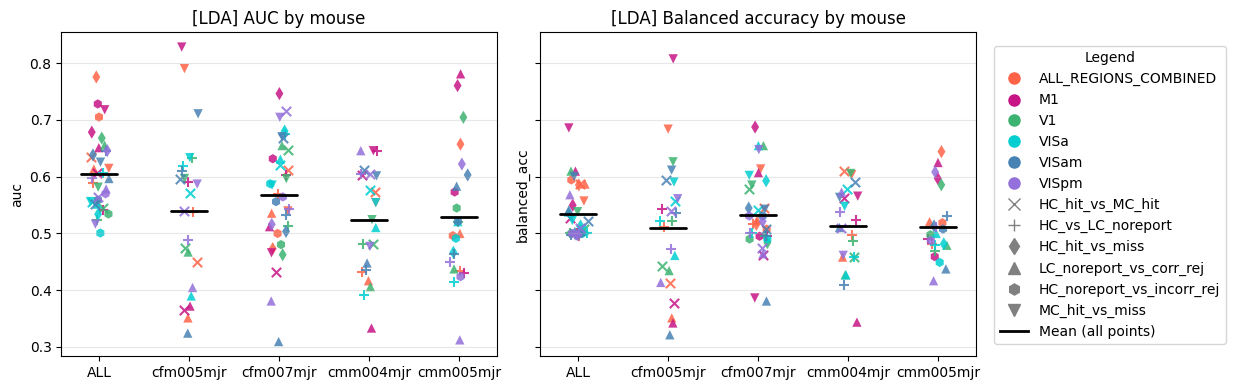

In [124]:
# 1) Collect LDA results (task x region for each mouse group)
rows = []
regions_all = sorted(df["region"].unique())
regions_plus = regions_all + ["ALL_REGIONS_COMBINED"]

for name, mice_list in mice_groups:
    for task_name, task_map in tasks.items():
        for region in regions_plus:

            if region == "ALL_REGIONS_COMBINED":
                df_sub = filter_df(df, regions="all", mice=mice_list)
                combine_regions = True
            else:
                df_sub = filter_df(df, regions=region, mice=mice_list)
                combine_regions = False

            df_lab = apply_task_map(df_sub, task_map, label_col="y")
            if len(df_lab) == 0:
                continue

            summ = run_decode_once_model(
                df_lab,
                model="lda",
                feature_prefix="log_",
                combine_regions=combine_regions,
                label_col="y",
                test_size=0.2,
                random_state=0,
            )

            rows.append({
                "mouse_group": name,
                "task": task_name,
                "region": region,
                "n_total": summ["n_total"],
                "class_counts": summ["class_counts"],
                "balanced_acc": summ["balanced_acc"],
                "auc": summ["auc"],
            })

all_res = pd.DataFrame(rows)

# 2) Filter small class counts
def min_class_count(class_counts):
    return int(min(class_counts.values())) if isinstance(class_counts, dict) and len(class_counts) else np.nan

all_res["min_class_n"] = all_res["class_counts"].apply(min_class_count)
before = len(all_res)
all_res = all_res[all_res["min_class_n"] >= MIN_PER_CLASS].copy()
after = len(all_res)
print(f"[LDA] Filtered runs by min class size >= {MIN_PER_CLASS}: {before} -> {after}")

# 3) Ordering + mappings
mouse_order = ["ALL"] + [name for name, _ in mice_groups if name != "ALL"]
all_res["mouse_group"] = pd.Categorical(all_res["mouse_group"], categories=mouse_order, ordered=True)

present_regions = sorted(all_res["region"].unique())
region_to_color = {r: region_colors[i] for i, r in enumerate(region_order) if r in present_regions}

present_tasks = sorted(all_res["task"].unique())
task_to_marker = {t: task_markers[i] for i, t in enumerate(task_order) if t in present_tasks}

from matplotlib.lines import Line2D

def plot_metric(ax, metric, title):
    # Points
    for (mouse_g, region, task), dsub in all_res.groupby(["mouse_group", "region", "task"], dropna=False):
        vals = dsub[metric].dropna().values
        if len(vals) == 0:
            continue

        x0 = mouse_order.index(str(mouse_g))
        x = np.full(len(vals), x0, dtype=float) + (np.random.rand(len(vals)) - 0.5) * 0.22

        ax.scatter(
            x,
            vals,
            s=45,
            alpha=0.85,
            marker=task_to_marker.get(task, "o"),
            color=region_to_color.get(region, "gray"),
            edgecolor="none",
        )

    # Mean line per mouse
    for i, mouse_g in enumerate(mouse_order):
        vals = all_res.loc[all_res["mouse_group"] == mouse_g, metric].dropna().values
        if len(vals) == 0:
            continue
        m = float(np.mean(vals))
        ax.plot([i - MEAN_LINE_HALF_WIDTH, i + MEAN_LINE_HALF_WIDTH], [m, m],
                color=MEAN_COLOR, linewidth=MEAN_LINE_LW, solid_capstyle="round", zorder=5)

    ax.set_xticks(range(len(mouse_order)))
    ax.set_xticklabels(mouse_order)
    ax.set_ylabel(metric)
    ax.set_title(title)
    #ax.set_ylim(0.44, 0.92)
    ax.grid(True, axis="y", alpha=0.3)

# Legend handles
region_handles = [
    Line2D([0], [0], marker="o", linestyle="None", markersize=8,
           markerfacecolor=region_to_color[r], markeredgecolor=region_to_color[r], label=r)
    for r in region_order if r in region_to_color
]
task_handles = [
    Line2D([0], [0], marker=task_to_marker[t], linestyle="None", markersize=8,
           markerfacecolor="gray", markeredgecolor="gray", label=t)
    for t in task_order if t in task_to_marker
]
mean_handle = Line2D([0], [0], color=MEAN_COLOR, linewidth=MEAN_LINE_LW, label=MEAN_LABEL)

handles = region_handles + task_handles + [mean_handle]

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4), sharey=True)

plot_metric(axes[0], "auc", f"[LDA] AUC by mouse")
plot_metric(axes[1], "balanced_acc", f"[LDA] Balanced accuracy by mouse")

fig.legend(
    handles=handles,
    loc="center right",
    bbox_to_anchor=(0.99, 0.5),
    frameon=True,
    title="Legend",
)

plt.tight_layout(rect=[0, 0, 0.80, 1])
plt.show()

## cross-validation

In [103]:
def _prep_Xy_groups(
    df_labeled: pd.DataFrame,
    feature_prefix="log_",
    combine_regions=False,
    label_col="y",
    group_col="recording",
):
    """
    Returns X, y, groups for CV.
    - combine_regions=False: expects one region selected already; uses one row per trial_id
    - combine_regions=True: concatenates region features per trial_id (wide pivot)
    groups are per-trial_id (so grouping is correct after pivoting).
    """
    if combine_regions:
        X_df, y_series = pivot_regions_wide(df_labeled, feature_prefix=feature_prefix, label_col=label_col)
        # Need group per trial_id: grab from df_labeled and align to X_df index (trial_id)
        g_map = df_labeled.drop_duplicates("trial_id").set_index("trial_id")[group_col]
        groups = g_map.loc[X_df.index].values
        X = X_df.values
        y = y_series.values
    else:
        d = df_labeled.drop_duplicates("trial_id").copy()
        feat_cols = [c for c in d.columns if c.startswith(feature_prefix)]
        X = d[feat_cols].values
        y = d[label_col].values
        groups = d[group_col].values

    return X, y, groups


def _class_counts_ok(y, min_per_class=100):
    uniq, cnt = np.unique(y, return_counts=True)
    if len(cnt) < 2:
        return False
    return (cnt.min() >= min_per_class)


def cv_decode_logo(
    df_labeled: pd.DataFrame,
    feature_prefix="log_",
    combine_regions=False,
    label_col="y",
    group_col="recording",
    min_per_class=100,
    class_weight="balanced",
    C=1.0,
    max_iter=3000,
):
    """
    Leave-one-group-out CV (group = recording OR mouse depending on group_col).
    Returns fold metrics + overall mean.
    """
    X, y, groups = _prep_Xy_groups(
        df_labeled,
        feature_prefix=feature_prefix,
        combine_regions=combine_regions,
        label_col=label_col,
        group_col=group_col,
    )

    if not _class_counts_ok(y, min_per_class=min_per_class):
        return None  # caller will skip

    logo = LeaveOneGroupOut()

    fold_rows = []
    for fold_idx, (tr, te) in enumerate(logo.split(X, y, groups=groups)):
        X_train, X_test = X[tr], X[te]
        y_train, y_test = y[tr], y[te]

        # Standardize within fold (fit on train only)
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test  = scaler.transform(X_test)

        clf = LogisticRegression(
            penalty="l2",
            class_weight=class_weight,
            C=C,
            max_iter=max_iter,
        )
        clf.fit(X_train, y_train)

        y_pred = clf.predict(X_test)
        bal = balanced_accuracy_score(y_test, y_pred)

        auc = np.nan
        if len(np.unique(y)) == 2 and len(np.unique(y_test)) == 2:
            y_prob = clf.predict_proba(X_test)[:, 1]
            auc = roc_auc_score(y_test, y_prob)

        fold_rows.append({
            "fold": fold_idx,
            "group_held_out": groups[te][0],  # all te belong to one group
            "n_test": int(len(te)),
            "balanced_acc": float(bal),
            "auc": float(auc) if not np.isnan(auc) else np.nan,
        })

    folds_df = pd.DataFrame(fold_rows)
    out = {
        "n_total": int(len(y)),
        "class_counts": dict(zip(*np.unique(y, return_counts=True))),
        "n_folds": int(len(folds_df)),
        "balanced_acc_mean": float(folds_df["balanced_acc"].mean()),
        "balanced_acc_std": float(folds_df["balanced_acc"].std(ddof=1)) if len(folds_df) > 1 else 0.0,
        "auc_mean": float(folds_df["auc"].mean(skipna=True)),
        "auc_std": float(folds_df["auc"].std(ddof=1, skipna=True)) if folds_df["auc"].notna().sum() > 1 else 0.0,
        "folds_df": folds_df,
    }
    return out


def evaluate_tasks_logo(
    df: pd.DataFrame,
    tasks: dict,
    feature_prefix="log_",
    mice_list=None,                 # e.g. ["cfm005mjr"] or all mice
    mode="LORO",                    # "LORO" or "LOMO"
    min_per_class=100,
    random_state=0,                # unused here, kept for consistency
):
    """
    Runs logistic regression with Leave-One-Group-Out CV.
    - mode="LORO": group_col="recording"
    - mode="LOMO": group_col="mouse"   (only meaningful when pooling multiple mice)
    Evaluates each region + ALL_REGIONS_COMBINED.
    Skips any (task,region) where either class has < min_per_class trials.
    """
    group_col = "recording" if mode.upper() == "LORO" else "mouse"

    results = []
    regions_all = sorted(df["region"].unique())
    regions_plus = regions_all + ["ALL_REGIONS_COMBINED"]

    for task_name, task_map in tasks.items():
        for region in regions_plus:

            if region == "ALL_REGIONS_COMBINED":
                df_sub = filter_df(df, regions="all", mice=mice_list)
                combine_regions = True
            else:
                df_sub = filter_df(df, regions=region, mice=mice_list)
                combine_regions = False

            df_lab = apply_task_map(df_sub, task_map, label_col="y")
            if len(df_lab) == 0:
                continue

            out = cv_decode_logo(
                df_lab,
                feature_prefix=feature_prefix,
                combine_regions=combine_regions,
                label_col="y",
                group_col=group_col,
                min_per_class=min_per_class,
            )
            if out is None:
                continue

            results.append({
                "task": task_name,
                "region": region,
                "cv": mode.upper(),
                "group_col": group_col,
                "n_total": out["n_total"],
                "class_counts": out["class_counts"],
                "n_folds": out["n_folds"],
                "balanced_acc_mean": out["balanced_acc_mean"],
                "balanced_acc_std": out["balanced_acc_std"],
                "auc_mean": out["auc_mean"],
                "auc_std": out["auc_std"],
            })

    res_df = pd.DataFrame(results)
    if len(res_df) > 0:
        res_df["class_counts_str"] = res_df["class_counts"].apply(
            lambda d: ", ".join([f"{k}:{v}" for k, v in d.items()])
        )
        res_df = res_df.sort_values(["task", "auc_mean"], ascending=[True, False]).reset_index(drop=True)

    return res_df



In [125]:
mice_all = ['cfm005mjr', 'cfm007mjr', 'cmm004mjr', 'cmm005mjr']

# 1) Leave-one-recording-out (pooled all mice)
res_loro_all = evaluate_tasks_logo(
    df=df,
    tasks=tasks,
    feature_prefix="log_",
    mice_list=mice_all,
    mode="LORO",
    min_per_class=100,
)
#display(res_loro_all[["task","region","n_total","class_counts_str","n_folds","balanced_acc_mean","auc_mean","balanced_acc_std","auc_std"]])

# 2) Leave-one-recording-out (per mouse)
res_loro_per_mouse = []
for m in mice_all:
    r = evaluate_tasks_logo(
        df=df,
        tasks=tasks,
        feature_prefix="log_",
        mice_list=[m],
        mode="LORO",
        min_per_class=100,
    )
    r["mouse"] = m
    res_loro_per_mouse.append(r)

res_loro_per_mouse = pd.concat(res_loro_per_mouse, ignore_index=True) if len(res_loro_per_mouse) else pd.DataFrame()
#display(res_loro_per_mouse[["mouse","task","region","n_total","class_counts_str","n_folds","balanced_acc_mean","auc_mean"]])

In [126]:
res_lomo = evaluate_tasks_logo(
    df=df,
    tasks=tasks,
    feature_prefix="log_",
    mice_list=mice_all,
    mode="LOMO",
    min_per_class=100,
)
display(res_lomo[["task","region","n_total","class_counts_str","n_folds","balanced_acc_mean","auc_mean","balanced_acc_std","auc_std"]])

,task,region,n_total,class_counts_str,n_folds,balanced_acc_mean,auc_mean,balanced_acc_std,auc_std
0,HC_hit_vs_MC_hit,ALL_REGIONS_COMBINED,1169,"0.0:386, 1.0:783",4,0.538506,0.567978,0.070100,0.078040
1,HC_hit_vs_MC_hit,M1,1169,"0.0:386, 1.0:783",4,0.544731,0.561854,0.042566,0.016092
2,HC_hit_vs_MC_hit,VISam,1169,"0.0:386, 1.0:783",4,0.503405,0.515762,0.079634,0.108769
3,HC_hit_vs_MC_hit,VISa,1169,"0.0:386, 1.0:783",4,0.485830,0.500361,0.081817,0.123637
4,HC_hit_vs_MC_hit,VISpm,1169,"0.0:386, 1.0:783",4,0.492468,0.491305,0.080573,0.097087
5,HC_hit_vs_MC_hit,V1,1169,"0.0:386, 1.0:783",4,0.484144,0.467493,0.042301,0.064079
6,HC_hit_vs_miss,M1,951,"0.0:168, 1.0:783",4,0.644535,0.700011,0.061103,0.061160
7,HC_hit_vs_miss,ALL_REGIONS_COMBINED,951,"0.0:168, 1.0:783",4,0.596761,0.652787,0.031967,0.036708
8,HC_hit_vs_miss,V1,951,"0.0:168, 1.0:783",4,0.531701,0.524985,0.049517,0.019765
9,HC_hit_vs_miss,VISa,951,"0.0:168, 1.0:783",4,0.477634,0.488855,0.064268,0.093376


In [130]:
# Define mouse groups (same pattern as before)
mice_groups = [
    ("ALL", mice),
    ("cfm005mjr", ["cfm005mjr"]),
    ("cfm007mjr", ["cfm007mjr"]),
    ("cmm004mjr", ["cmm004mjr"]),
    ("cmm005mjr", ["cmm005mjr"]),
]

# 1) Collect LORO results (task x region for each mouse group)
rows = []
regions_all = sorted(df["region"].unique())
regions_plus = regions_all + ["ALL_REGIONS_COMBINED"]

for name, mice_list in mice_groups:
    for task_name, task_map in tasks.items():
        for region in regions_plus:

            if region == "ALL_REGIONS_COMBINED":
                df_sub = filter_df(df, regions="all", mice=mice_list)
                combine_regions = True
            else:
                df_sub = filter_df(df, regions=region, mice=mice_list)
                combine_regions = False

            df_lab = apply_task_map(df_sub, task_map, label_col="y")
            if len(df_lab) == 0:
                continue

            out = cv_decode_logo(
                df_lab,
                feature_prefix="log_",
                combine_regions=combine_regions,
                label_col="y",
                group_col="recording",       # LORO
                min_per_class=MIN_PER_CLASS,
                class_weight="balanced",
                C=1.0,
            )
            if out is None:
                continue

            rows.append({
                "mouse_group": name,
                "task": task_name,
                "region": region,
                "n_total": out["n_total"],
                "class_counts": out["class_counts"],
                "n_folds": out["n_folds"],
                # Use CV mean metrics as the plotted points
                "balanced_acc": out["balanced_acc_mean"],
                "auc": out["auc_mean"],
            })

all_res = pd.DataFrame(rows)

# 2) Filter small class counts (redundant with cv_decode_logo's gate, but kept for symmetry)
def min_class_count(class_counts):
    return int(min(class_counts.values())) if isinstance(class_counts, dict) and len(class_counts) else np.nan

all_res["min_class_n"] = all_res["class_counts"].apply(min_class_count)
before = len(all_res)
all_res = all_res[all_res["min_class_n"] >= MIN_PER_CLASS].copy()
after = len(all_res)
print(f"[LORO] Filtered runs by min class size >= {MIN_PER_CLASS}: {before} -> {after}")

# 3) Ordering + mappings
mouse_order = ["ALL"] + [name for name, _ in mice_groups if name != "ALL"]
all_res["mouse_group"] = pd.Categorical(all_res["mouse_group"], categories=mouse_order, ordered=True)

present_regions = sorted(all_res["region"].unique())
region_to_color = {r: region_colors[i] for i, r in enumerate(region_order) if r in present_regions}

present_tasks = sorted(all_res["task"].unique())
task_to_marker = {t: task_markers[i] for i, t in enumerate(task_order) if t in present_tasks}

from matplotlib.lines import Line2D

def plot_metric(ax, metric, title):
    # Points (one per (mouse_group, region, task))
    for (mouse_g, region, task), dsub in all_res.groupby(["mouse_group", "region", "task"], dropna=False):
        vals = dsub[metric].dropna().values
        if len(vals) == 0:
            continue

        x0 = mouse_order.index(str(mouse_g))
        x = np.full(len(vals), x0, dtype=float) + (np.random.rand(len(vals)) - 0.5) * 0.22

        ax.scatter(
            x,
            vals,
            s=45,
            alpha=0.85,
            marker=task_to_marker.get(task, "o"),
            color=region_to_color.get(region, "gray"),
            edgecolor="none",
        )

    # Mean line per mouse_group (mean across all plotted points for that mouse_group)
    for i, mouse_g in enumerate(mouse_order):
        vals = all_res.loc[all_res["mouse_group"] == mouse_g, metric].dropna().values
        if len(vals) == 0:
            continue
        m = float(np.mean(vals))
        ax.plot(
            [i - MEAN_LINE_HALF_WIDTH, i + MEAN_LINE_HALF_WIDTH],
            [m, m],
            color=MEAN_COLOR,
            linewidth=MEAN_LINE_LW,
            solid_capstyle="round",
            zorder=5,
        )

    ax.set_xticks(range(len(mouse_order)))
    ax.set_xticklabels(mouse_order)
    ax.set_ylabel(metric)
    ax.set_title(title)
    #ax.set_ylim(0.4, 0.92)
    ax.grid(True, axis="y", alpha=0.3)

# Legend handles (same style as your snippet)
region_handles = [
    Line2D([0], [0], marker="o", linestyle="None", markersize=8,
           markerfacecolor=region_to_color[r], markeredgecolor=region_to_color[r], label=r)
    for r in region_order if r in region_to_color
]
task_handles = [
    Line2D([0], [0], marker=task_to_marker[t], linestyle="None", markersize=8,
           markerfacecolor="gray", markeredgecolor="gray", label=t)
    for t in task_order if t in task_to_marker
]
mean_handle = Line2D([0], [0], color=MEAN_COLOR, linewidth=MEAN_LINE_LW, label=MEAN_LABEL)

handles = region_handles + task_handles + [mean_handle]

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4), sharey=True)

plot_metric(axes[0], "auc", "[LORO] AUC by mouse")
plot_metric(axes[1], "balanced_acc", "[LORO] Balanced accuracy by mouse")

fig.legend(
    handles=handles,
    loc="center right",
    bbox_to_anchor=(0.99, 0.5),
    frameon=True,
    title="Legend",
)

plt.tight_layout(rect=[0, 0, 0.80, 1])
plt.show()

[LORO] Filtered runs by min class size >= 25: 144 -> 144


KeyError: 0

Fold-level rows: 2037


,fold,group_held_out,n_test,balanced_acc,auc,mouse_group,task,region
0,0,\cfm005mjr\20251202\meas00\trial_spectrograms....,20,0.781250,0.843750,ALL,HC_hit_vs_MC_hit,M1
1,1,\cfm005mjr\20251202\meas01\trial_spectrograms....,33,0.431818,0.500000,ALL,HC_hit_vs_MC_hit,M1
2,2,\cfm005mjr\20251202\meas02\trial_spectrograms....,17,0.416667,0.428571,ALL,HC_hit_vs_MC_hit,M1
3,3,\cfm005mjr\20251202\meas03\trial_spectrograms....,3,0.250000,0.000000,ALL,HC_hit_vs_MC_hit,M1
4,4,\cfm005mjr\20251202\meas04\trial_spectrograms....,1,1.000000,NaN,ALL,HC_hit_vs_MC_hit,M1


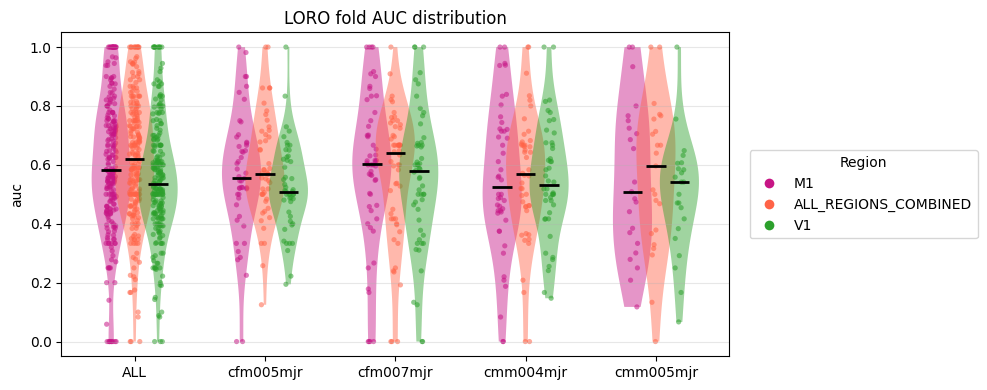

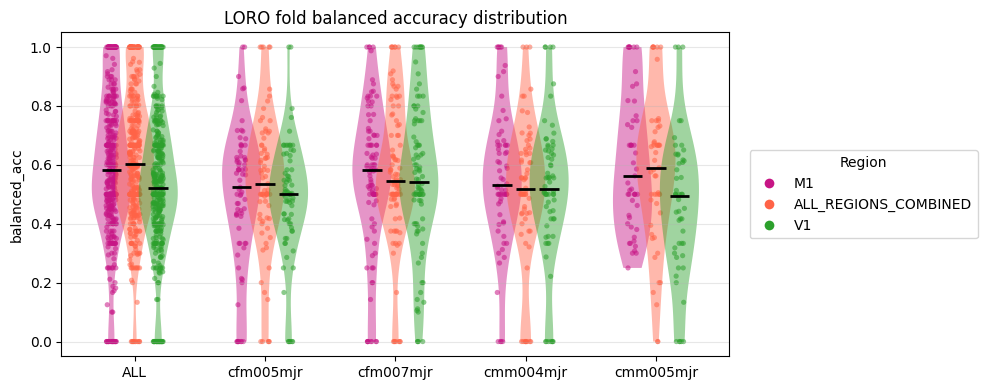

In [131]:
# Violin plots of LORO fold performance across held-out recordings.
# Shows spread across folds (recordings) much better than the task/region/mouse scatter.

MIN_PER_CLASS = 25

region_colors = {
    "M1": "mediumvioletred",
    "ALL_REGIONS_COMBINED": "tomato",
    # "V1": "mediumseagreen",
    "VISa": "darkturquoise",
    # "VISam": "steelblue",
    # "VISpm": "mediumpurple",
}


# Choose what to include (keep it readable)
mice_groups = [
    ("ALL", mice),
    ("cfm005mjr", ["cfm005mjr"]),
    ("cfm007mjr", ["cfm007mjr"]),
    ("cmm004mjr", ["cmm004mjr"]),
    ("cmm005mjr", ["cmm005mjr"]),
]

# Pick which regions to plot folds for (you can add more, but it gets busy)
regions_to_plot = ["M1", "ALL_REGIONS_COMBINED", "V1"]  # change as desired
tasks_to_plot = list(tasks.keys())                # or choose a subset, e.g. ["task_hit_vs_noreport"]

# --- Collect fold-level results ---
fold_rows = []

regions_all = sorted(df["region"].unique())
regions_plus = regions_all + ["ALL_REGIONS_COMBINED"]

for mouse_group, mice_list in mice_groups:
    for task_name in tasks_to_plot:
        task_map = tasks[task_name]

        for region in regions_to_plot:
            if region not in regions_plus:
                continue

            if region == "ALL_REGIONS_COMBINED":
                df_sub = filter_df(df, regions="all", mice=mice_list)
                combine_regions = True
            else:
                df_sub = filter_df(df, regions=region, mice=mice_list)
                combine_regions = False

            df_lab = apply_task_map(df_sub, task_map, label_col="y")
            if len(df_lab) == 0:
                continue

            out = cv_decode_logo(
                df_lab,
                feature_prefix="log_",
                combine_regions=combine_regions,
                label_col="y",
                group_col="recording",       # LORO folds
                min_per_class=MIN_PER_CLASS,
                class_weight="balanced",
                C=1.0,
            )
            if out is None:
                continue

            folds_df = out["folds_df"].copy()
            folds_df["mouse_group"] = mouse_group
            folds_df["task"] = task_name
            folds_df["region"] = region
            fold_rows.append(folds_df)

fold_res = pd.concat(fold_rows, ignore_index=True) if len(fold_rows) else pd.DataFrame()
print("Fold-level rows:", len(fold_res))
display(fold_res.head())

# --- Plot: violin per mouse_group, faceted by metric, split by region (color) ---
# We avoid seaborn to keep dependencies minimal.
def violin_by_mouse(fold_res, metric="auc", title=""):
    plt.figure(figsize=(10, 4))

    mouse_order = ["ALL"] + [mg for mg, _ in mice_groups if mg != "ALL"]
    fold_res = fold_res.copy()
    fold_res["mouse_group"] = pd.Categorical(fold_res["mouse_group"], categories=mouse_order, ordered=True)

    # x positions
    xs = np.arange(len(mouse_order))

    # region colors (simple)
    region_list = [r for r in regions_to_plot if r in fold_res["region"].unique()]
    # Use user-specified colors; fall back to matplotlib defaults if missing
    region_color = {r: region_colors.get(r, f"C{i}") for i, r in enumerate(region_list)}

    # draw one violin per mouse per region (offset a bit)
    offsets = np.linspace(-0.18, 0.18, num=len(region_list)) if len(region_list) > 1 else [0.0]

    for r_i, region in enumerate(region_list):
        off = offsets[r_i]
        for i, mg in enumerate(mouse_order):
            vals = fold_res[(fold_res["mouse_group"] == mg) & (fold_res["region"] == region)][metric].dropna().values
            if len(vals) == 0:
                continue

            parts = plt.violinplot(
                dataset=[vals],
                positions=[i + off],
                widths=0.30 if len(region_list) > 1 else 0.55,
                showmeans=False,
                showmedians=True,
                showextrema=False,
            )
            for pc in parts["bodies"]:
                pc.set_alpha(0.45)
                pc.set_facecolor(region_color[region])
                pc.set_edgecolor("none")
            parts["cmedians"].set_color("black")
            parts["cmedians"].set_linewidth(2)

            # overlay points (jitter)
            jitter = (np.random.rand(len(vals)) - 0.5) * 0.08
            plt.scatter(np.full(len(vals), i + off) + jitter, vals, s=14, alpha=0.55, color=region_color[region], edgecolor="none")

    plt.xticks(xs, mouse_order)
    plt.ylabel(metric)
    #plt.ylim(0.35, 0.95)
    plt.title(title)
    plt.grid(True, axis="y", alpha=0.3)

    # legend
    handles = [Line2D([0], [0], marker="o", linestyle="None", markersize=7,
                      markerfacecolor=region_color[r], markeredgecolor="none", label=r)
               for r in region_list]
    plt.legend(handles=handles, title="Region", loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=True)

    plt.tight_layout()
    plt.show()

violin_by_mouse(fold_res, metric="auc", title=f"LORO fold AUC distribution")
violin_by_mouse(fold_res, metric="balanced_acc", title=f"LORO fold balanced accuracy distribution")

In [115]:
# Find held-out recordings (folds) with very low performance.
# Assumes you have fold_res from the LORO fold-level collection step.
# fold_res columns should include: ["task","region","mouse_group","group_held_out","auc","balanced_acc"]

THRESH = 0.10  # start here; you can change to 0.5, 0.6, etc.

def find_bad_folds(fold_res: pd.DataFrame, metric: str, thresh: float = 0.10):
    bad = fold_res.loc[fold_res[metric].notna() & (fold_res[metric] < thresh)].copy()
    if len(bad) == 0:
        print(f"No folds found with {metric} < {thresh}")
        return bad

    cols = ["mouse_group", "task", "region", "group_held_out", "n_test", metric]
    bad = bad[cols].sort_values([metric, "mouse_group", "task", "region"]).reset_index(drop=True)

    print(f"Found {len(bad)} folds with {metric} < {thresh}")
    display(bad)
    return bad

bad_auc = find_bad_folds(fold_res, metric="auc", thresh=THRESH)
bad_bal = find_bad_folds(fold_res, metric="balanced_acc", thresh=THRESH)

# If you just want the unique recording names:
print("\nUnique held-out recordings with AUC < thresh:")
print(sorted(bad_auc["group_held_out"].unique().tolist()) if len(bad_auc) else [])

print("\nUnique held-out recordings with balanced_acc < thresh:")
print(sorted(bad_bal["group_held_out"].unique().tolist()) if len(bad_bal) else [])

Found 14 folds with auc < 0.1


,mouse_group,task,region,group_held_out,n_test,auc
0,ALL,task_MC_hit_vs_miss,M1,\cfm007mjr\20251210\meas00\trial_spectrograms....,3,0.000000
1,ALL,task_MC_hit_vs_miss,V1,\cfm007mjr\20251209\meas03\trial_spectrograms....,2,0.000000
2,ALL,task_MC_report_vs_noreport,V1,\cmm004mjr\20251204\meas04\trial_spectrograms....,27,0.000000
3,ALL,task_hit_vs_miss,V1,\cmm005mjr\20251128\meas03\trial_spectrograms....,2,0.000000
4,ALL,task_hit_vs_miss,V1,\cmm005mjr\20251128\meas04\trial_spectrograms....,5,0.000000
5,cfm005mjr,task_MC_report_vs_noreport,V1,\cfm005mjr\20251202\meas04\trial_spectrograms....,9,0.000000
6,cmm004mjr,task_MC_hit_vs_miss,ALL_REGIONS_COMBINED,\cmm004mjr\20251205\meas04\trial_spectrograms....,2,0.000000
7,cmm004mjr,task_MC_hit_vs_miss,M1,\cmm004mjr\20251205\meas04\trial_spectrograms....,2,0.000000
8,cfm005mjr,task_MC_report_vs_noreport,V1,\cfm005mjr\20251208\meas06\trial_spectrograms....,24,0.043478
9,ALL,task_MC_report_vs_noreport,V1,\cfm007mjr\20251207\meas04\trial_spectrograms....,22,0.047619


Found 44 folds with balanced_acc < 0.1


,mouse_group,task,region,group_held_out,n_test,balanced_acc
0,ALL,task_MC_hit_vs_miss,ALL_REGIONS_COMBINED,\cfm005mjr\20251202\meas03\trial_spectrograms....,1,0.000000
1,ALL,task_MC_hit_vs_miss,ALL_REGIONS_COMBINED,\cfm006mjr\20251210\meas01\trial_spectrograms....,1,0.000000
2,ALL,task_MC_hit_vs_miss,M1,\cfm005mjr\20251202\meas04\trial_spectrograms....,1,0.000000
3,ALL,task_MC_hit_vs_miss,M1,\cfm006mjr\20251210\meas01\trial_spectrograms....,1,0.000000
4,ALL,task_MC_hit_vs_miss,M1,\cmm004mjr\20251204\meas04\trial_spectrograms....,1,0.000000
5,ALL,task_MC_hit_vs_miss,V1,\cfm005mjr\20251202\meas03\trial_spectrograms....,1,0.000000
6,ALL,task_MC_hit_vs_miss,V1,\cfm006mjr\20251210\meas01\trial_spectrograms....,1,0.000000
7,ALL,task_MC_hit_vs_miss,V1,\cfm007mjr\20251211\meas00\trial_spectrograms....,4,0.000000
8,ALL,task_MC_hit_vs_miss,V1,\cmm004mjr\20251203\meas03\trial_spectrograms....,1,0.000000
9,ALL,task_MC_hit_vs_miss,V1,\cmm004mjr\20251204\meas04\trial_spectrograms....,1,0.000000



Unique held-out recordings with AUC < thresh:
['\\cfm005mjr\\20251202\\meas04\\trial_spectrograms.zarr', '\\cfm005mjr\\20251208\\meas06\\trial_spectrograms.zarr', '\\cfm007mjr\\20251207\\meas04\\trial_spectrograms.zarr', '\\cfm007mjr\\20251209\\meas03\\trial_spectrograms.zarr', '\\cfm007mjr\\20251210\\meas00\\trial_spectrograms.zarr', '\\cmm004mjr\\20251204\\meas04\\trial_spectrograms.zarr', '\\cmm004mjr\\20251205\\meas04\\trial_spectrograms.zarr', '\\cmm005mjr\\20251127\\meas04\\trial_spectrograms.zarr', '\\cmm005mjr\\20251128\\meas03\\trial_spectrograms.zarr', '\\cmm005mjr\\20251128\\meas04\\trial_spectrograms.zarr']

Unique held-out recordings with balanced_acc < thresh:
['\\cfm005mjr\\20251202\\meas03\\trial_spectrograms.zarr', '\\cfm005mjr\\20251202\\meas04\\trial_spectrograms.zarr', '\\cfm005mjr\\20251207\\meas03\\trial_spectrograms.zarr', '\\cfm005mjr\\20251208\\meas05\\trial_spectrograms.zarr', '\\cfm005mjr\\20251208\\meas06\\trial_spectrograms.zarr', '\\cfm006mjr\\20251210\\m

In [116]:
THRESH = 0.10  # adjust if needed

# 1) Identify low-performing folds for each metric
low_auc = fold_res.loc[
    fold_res["auc"].notna() & (fold_res["auc"] < THRESH)
].copy()
low_auc["failed_metric"] = "AUC"

low_acc = fold_res.loc[
    fold_res["balanced_acc"].notna() & (fold_res["balanced_acc"] < THRESH)
].copy()
low_acc["failed_metric"] = "balanced_acc"

# 2) Combine them
low_all = pd.concat([low_auc, low_acc], ignore_index=True)

if len(low_all) == 0:
    print(f"No folds found with AUC or balanced_acc < {THRESH}")
else:
    print(f"Total suspicious fold entries: {len(low_all)}")

    # 3) Clean view
    cols = [
        "mouse_group",
        "group_held_out",
        "task",
        "region",
        "failed_metric",
        "auc",
        "balanced_acc",
        "n_test",
    ]

    low_all = low_all[cols].sort_values(
        ["group_held_out", "task", "region"]
    ).reset_index(drop=True)

    display(low_all)

    # 4) Higher-level grouped summary: what each recording failed
    summary = (
        low_all
        .groupby(["mouse_group", "group_held_out"])
        .apply(lambda d: pd.DataFrame({
            "n_failures": [len(d)],
            "tasks_failed": [sorted(d["task"].unique())],
            "regions_failed": [sorted(d["region"].unique())],
            "metrics_failed": [sorted(d["failed_metric"].unique())],
        }))
        .reset_index(level=[0,1])
        .reset_index(drop=True)
    )

    print("\nSummary per suspicious recording:")
    display(summary)

Total suspicious fold entries: 58


,mouse_group,group_held_out,task,region,failed_metric,auc,balanced_acc,n_test
0,ALL,\cfm005mjr\20251202\meas03\trial_spectrograms....,task_MC_hit_vs_miss,ALL_REGIONS_COMBINED,balanced_acc,NaN,0.000000,1
1,cfm005mjr,\cfm005mjr\20251202\meas03\trial_spectrograms....,task_MC_hit_vs_miss,ALL_REGIONS_COMBINED,balanced_acc,NaN,0.000000,1
2,ALL,\cfm005mjr\20251202\meas03\trial_spectrograms....,task_MC_hit_vs_miss,V1,balanced_acc,NaN,0.000000,1
3,ALL,\cfm005mjr\20251202\meas04\trial_spectrograms....,task_MC_hit_vs_miss,M1,balanced_acc,NaN,0.000000,1
4,cfm005mjr,\cfm005mjr\20251202\meas04\trial_spectrograms....,task_MC_hit_vs_miss,M1,balanced_acc,NaN,0.000000,1
5,cfm005mjr,\cfm005mjr\20251202\meas04\trial_spectrograms....,task_MC_hit_vs_miss,V1,balanced_acc,NaN,0.000000,1
6,cfm005mjr,\cfm005mjr\20251202\meas04\trial_spectrograms....,task_MC_report_vs_noreport,V1,AUC,0.000000,0.250000,9
7,ALL,\cfm005mjr\20251207\meas03\trial_spectrograms....,task_hit_vs_miss,V1,balanced_acc,NaN,0.000000,2
8,cfm005mjr,\cfm005mjr\20251207\meas03\trial_spectrograms....,task_hit_vs_miss,V1,balanced_acc,NaN,0.000000,2
9,cfm005mjr,\cfm005mjr\20251208\meas05\trial_spectrograms....,task_MC_report_vs_noreport,ALL_REGIONS_COMBINED,balanced_acc,NaN,0.095238,21



Summary per suspicious recording:


,mouse_group,group_held_out,n_failures,tasks_failed,regions_failed,metrics_failed
0,ALL,\cfm005mjr\20251202\meas03\trial_spectrograms....,2,[task_MC_hit_vs_miss],"[ALL_REGIONS_COMBINED, V1]",[balanced_acc]
1,ALL,\cfm005mjr\20251202\meas04\trial_spectrograms....,1,[task_MC_hit_vs_miss],[M1],[balanced_acc]
2,ALL,\cfm005mjr\20251207\meas03\trial_spectrograms....,1,[task_hit_vs_miss],[V1],[balanced_acc]
3,ALL,\cfm005mjr\20251208\meas06\trial_spectrograms....,1,[task_MC_report_vs_noreport],[V1],[AUC]
4,ALL,\cfm006mjr\20251210\meas01\trial_spectrograms....,3,[task_MC_hit_vs_miss],"[ALL_REGIONS_COMBINED, M1, V1]",[balanced_acc]
5,ALL,\cfm007mjr\20251207\meas04\trial_spectrograms....,1,[task_MC_report_vs_noreport],[V1],[AUC]
6,ALL,\cfm007mjr\20251209\meas03\trial_spectrograms....,1,[task_MC_hit_vs_miss],[V1],[AUC]
7,ALL,\cfm007mjr\20251210\meas00\trial_spectrograms....,2,"[task_MC_hit_vs_miss, task_MC_report_vs_noreport]","[M1, V1]","[AUC, balanced_acc]"
8,ALL,\cfm007mjr\20251211\meas00\trial_spectrograms....,4,"[task_MC_hit_vs_miss, task_MC_report_vs_norepo...","[ALL_REGIONS_COMBINED, V1]",[balanced_acc]
9,ALL,\cmm004mjr\20251201\meas04\trial_spectrograms....,1,[task_hit_vs_miss],[V1],[balanced_acc]
